## 4. Hydraulic conductivity

### Set up hydraulic-conductivity inputs

Defines input paths, output workspace, constants, and basic environment settings for the surficial geology to HK workflow.

In [29]:
import os
import arcpy
from arcpy.sa import Raster, SetNull

# Ensure Spatial Analyst is available and outputs can be overwritten
arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

print("Libraries loaded. Environment set.")


# Ensure Spatial Analyst is available and outputs can be overwritten
arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

print("Libraries loaded. Environment set.")

## 1. Define File Paths and Constants
#Here we define the locations of the raw shapefiles, the CSV containing the parameters, the target template grid, and our conductivity constants.

# ============================================================
# INPUTS
# ============================================================
# path file to geology shapefile with surficial units (must have "POLYID" column for joining with Excel)
surfacegeology = r"S:\Data\Other_Data\Xu_2021\Data\09_Integrated_Surficial_Geology_Map\Integrated_surficial_geology_mapping.shp"
# path to calibrated HK values for surficial units (must have "unit_code" column matching the geology shapefile)
excel_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\Calibrated_surficial_Kh.xlsx"
in_sheet = rf"{excel_path}\GLB_surf_dissolve_merged$"
# extended model boundary with 2000 m buffer (for sampling HK beyond the lake bands)
extended_Buffer2km = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\boundary_buffer_2000m.shp"
# IBOUND raster for 2000 meter buffer boundary (1=active, 0=inactive,-1=lake) 
water_mask_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff20000m.tif"
# template raster to define the output grid and alignment (must have same CRS and resolution as model grid)
template_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"
lake_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"

MI_KRIG_UP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\UP_hkBulk_3174.tif"
MI_KRIG_LP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\LP_hkBulk_3174.tif"
model_Bdry = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"

# OUTPUT DIRECTORY
out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"
os.makedirs(out_dir, exist_ok=True)
gdb = os.path.join(out_dir, "HK_join_clip.gdb")
if not arcpy.Exists(gdb):
    arcpy.management.CreateFileGDB(out_dir, os.path.basename(gdb))

# ============================================================
# CONSTANTS & VALUES
# ============================================================
SEC_PER_DAY = 86400.0
LAKE_RASTER_VALUE = -1

# Kh Values (m/s)
LOWER_DEFAULT_MS = 1e-7      
FRAC_BEDROCK_MS  = 1e-6
BEDROCK_MS       = 1e-10

# Kh Values (m/day)
FRAC_BEDROCK_MDAY = FRAC_BEDROCK_MS * SEC_PER_DAY # 0.0864
BEDROCK_MDAY      = BEDROCK_MS * SEC_PER_DAY      # 0.0000864

# Values to burn into Lake / Land cells
LAKE_VALUE = 100.0
LAND_VALUE = 0.0

print("Paths and Constants Defined.")


Libraries loaded. Environment set.
Libraries loaded. Environment set.
Paths and Constants Defined.


### Helper functions for joins and geometry operations

Provides reusable helpers for deleting temporary data, making join fields, clipping, and erasing. These support the HK polygon processing workflow.

In [2]:
def delete_if_exists(p):
    if p and arcpy.Exists(p):
        arcpy.management.Delete(p)

def ensure_field(dataset, name, ftype, length=None):
    existing = {f.name for f in arcpy.ListFields(dataset)}
    if name not in existing:
        if ftype.upper() == "TEXT" and length is not None:
            arcpy.management.AddField(dataset, name, ftype, field_length=length)
        else:
            arcpy.management.AddField(dataset, name, ftype)

def make_join_id(dataset, source_field, join_field="JOIN_ID"):
    ensure_field(dataset, join_field, "TEXT", length=50)
    codeblock = """def to_key(v):
    if v is None: return None
    s = str(v).strip()
    if s == "": return None
    try:
        fv = float(s)
        if fv.is_integer(): s = str(int(fv))
        else: s = str(fv)
    except: pass
    return s.strip().upper()"""
    arcpy.management.CalculateField(dataset, join_field, f"to_key(!{source_field}!)", "PYTHON3", code_block=codeblock)
    
def safe_clip(in_fc, clip_fc, out_fc):
    delete_if_exists(out_fc)
    if hasattr(arcpy.analysis, "PairwiseClip"): arcpy.analysis.PairwiseClip(in_fc, clip_fc, out_fc)
    else: arcpy.analysis.Clip(in_fc, clip_fc, out_fc)

def safe_erase(in_fc, erase_fc, out_fc):
    delete_if_exists(out_fc)
    if hasattr(arcpy.analysis, "PairwiseErase"): arcpy.analysis.PairwiseErase(in_fc, erase_fc, out_fc)
    else: arcpy.analysis.Erase(in_fc, erase_fc, out_fc)

### Copy geology data and join calibrated HK attributes

Copies the source geology layer into a geodatabase, imports the calibrated HK CSV, standardizes join keys, and joins the tabular conductivity attributes to the geology polygons.
mathching columns of Zone* from calibrated HK and Polygon_ID 

In [3]:
# output feature class paths
surf_fc = os.path.join(gdb, "surfacegeology_base")
csv_tbl = os.path.join(gdb, "Kh_csv_tbl")
joined_fc = os.path.join(gdb, "surfacegeo_joined")


print("Copying Geology to GDB...")
delete_if_exists(surf_fc)
arcpy.management.CopyFeatures(surfacegeology, surf_fc)

print("Importing CSV to GDB...")

delete_if_exists(csv_tbl)
arcpy.conversion.TableToTable(in_sheet, gdb, "Kh_csv_tbl")

tbl_fields = [f.name for f in arcpy.ListFields(csv_tbl)]
if "Lower_ms" not in tbl_fields:
    ensure_field(csv_tbl, "Lower_ms", "DOUBLE")
    arcpy.management.CalculateField(csv_tbl, "Lower_ms", str(LOWER_DEFAULT_MS), "PYTHON3")

print("Processing Join Keys...")
# Note: Ensure that "col_1" is your actual ID field in the CSV matching "POLYID"
make_join_id(surf_fc, "POLYID", "JOIN_ID")
make_join_id(csv_tbl, "Zone_", "JOIN_ID")

print("Joining Data...")
delete_if_exists(joined_fc)
arcpy.management.CopyFeatures(surf_fc, joined_fc)
csv_fields_to_add = [f.name for f in arcpy.ListFields(csv_tbl) if f.type not in ("OID", "Geometry") and f.name.lower() != "join_id"]
arcpy.management.JoinField(joined_fc, "JOIN_ID", csv_tbl, "JOIN_ID", csv_fields_to_add)

print(f"✅ Join Complete. Added {len(csv_fields_to_add)} attributes.")


Copying Geology to GDB...
Importing CSV to GDB...
Processing Join Keys...
Joining Data...
✅ Join Complete. Added 6 attributes.


### Calculate five MODFLOW HK layers

Calculates the final five hydraulic-conductivity fields in m/day for the MODFLOW layers: upper, middle, lower, fractured bedrock, and bedrock.

In [4]:
# The 5 HK fields required by MODFLOW
fields_5_layers = ["UPKh_m_d", "MidKh_m_d", "LowKh_m_d", "FracKh_m_d", "BedKh_m_d"]

print("Checking joined_fc fields...")
joined_fields = [f.name for f in arcpy.ListFields(joined_fc)]
print(joined_fields)

print("Calculating 5-Layer HK fields in m/day...")
for fld in fields_5_layers:
    ensure_field(joined_fc, fld, "DOUBLE")

# Actual source field names in joined_fc
upper_src  = "Kh__m_s_"
middle_src = "Kh__m_s_1"
lower_src  = "Lower_ms"

missing = [f for f in [upper_src, middle_src, lower_src] if f not in joined_fields]
if missing:
    raise ValueError(f"Missing expected field(s) in joined_fc: {missing}")

codeblock = """
def to_float(v):
    try:
        if v is None:
            return None
        s = str(v).strip()
        if s == "":
            return None
        return float(s)
    except:
        return None
"""

# Surficial Soil Layers (m/s to m/day)
arcpy.management.CalculateField(
    joined_fc, "UPKh_m_d",
    f"to_float(!{upper_src}!) * {SEC_PER_DAY}",
    "PYTHON3", codeblock
)

arcpy.management.CalculateField(
    joined_fc, "MidKh_m_d",
    f"to_float(!{middle_src}!) * {SEC_PER_DAY}",
    "PYTHON3", codeblock
)

arcpy.management.CalculateField(
    joined_fc, "LowKh_m_d",
    f"to_float(!{lower_src}!) * {SEC_PER_DAY}",
    "PYTHON3", codeblock
)

# Deep Constant Bedrock Layers
arcpy.management.CalculateField(
    joined_fc, "FracKh_m_d",
    str(FRAC_BEDROCK_MDAY),
    "PYTHON3"
)

arcpy.management.CalculateField(
    joined_fc, "BedKh_m_d",
    str(BEDROCK_MDAY),
    "PYTHON3"
)

print("✅ 5 Stratigraphy Layers calculated.")

Checking joined_fc fields...
['OBJECTID', 'Shape', 'POLYID', 'JOIN_ID', 'Shape_Length', 'Shape_Area', 'Zone_', 'Polygon_ID', 'Description', 'Kh__m_s_', 'Kh__m_s_1', 'Lower_ms']
Calculating 5-Layer HK fields in m/day...
✅ 5 Stratigraphy Layers calculated.


### Clip HK polygons to the model domain and apply lake values

Clips the geology/HK polygons to the buffered model domain, extracts lake polygons from the water mask, splits land and lake portions, and assigns lake HK values where needed.

In [6]:
from arcpy.sa import Raster, SetNull, Int

print("Clipping to Domain Buffer...")

# ------------------------------------------------------------
# inputs / outputs
# ------------------------------------------------------------
domain_fc    = os.path.join(gdb, "domain_buffer2km_proj")
clip_fc      = os.path.join(gdb, "surfacegeo_joined_clip2km")

lake_ras     = os.path.join(gdb, "lake_ras")
lake_poly0   = os.path.join(gdb, "lake_raw")
lake_poly    = os.path.join(gdb, "lake_diss")
lake_domain  = os.path.join(gdb, "lake_in_domain")

lake_part    = os.path.join(gdb, "hk_lake_part")
land_part    = os.path.join(gdb, "hk_land_part")
lake_missing = os.path.join(gdb, "hk_lake_missing")

final_fc     = os.path.join(gdb, "surfacegeo_HK_FINAL")

# ------------------------------------------------------------
# make sure this matches your raster coding
# lake cells in water_mask_raster = -1
# ------------------------------------------------------------
LAKE_RASTER_VALUE = -1

# ------------------------------------------------------------
# project domain buffer if needed
# ------------------------------------------------------------
buf_sr = arcpy.Describe(extended_Buffer2km).spatialReference
fc_sr  = arcpy.Describe(joined_fc).spatialReference

delete_if_exists(domain_fc)
if fc_sr.factoryCode == buf_sr.factoryCode:
    arcpy.management.CopyFeatures(extended_Buffer2km, domain_fc)
else:
    arcpy.management.Project(extended_Buffer2km, domain_fc, fc_sr)

# ------------------------------------------------------------
# clip joined geology to domain
# ------------------------------------------------------------
delete_if_exists(clip_fc)
safe_clip(joined_fc, domain_fc, clip_fc)

# ------------------------------------------------------------
# extract lake polygons from raster mask
# keeps only cells == -1, makes them value 1, everything else NoData
# Int() makes sure RasterToPolygon gets an integer raster
# ------------------------------------------------------------
print("Extracting Lake boundaries from raster...")

for p in [lake_ras, lake_poly0, lake_poly]:
    delete_if_exists(p)

ras = Raster(water_mask_raster)
Int(SetNull(ras != LAKE_RASTER_VALUE, 1)).save(lake_ras)

arcpy.conversion.RasterToPolygon(lake_ras, lake_poly0, "SIMPLIFY", "VALUE")
arcpy.management.Dissolve(lake_poly0, lake_poly)

# ------------------------------------------------------------
# clip lake polygons to model domain
# ------------------------------------------------------------
print("Splitting Geometry to Land and Lakes...")

for p in [lake_domain, lake_part, land_part, lake_missing]:
    delete_if_exists(p)

safe_clip(lake_poly, domain_fc, lake_domain)

# parts:
# 1) geology that overlaps lake polygons
# 2) geology on land only
# 3) any lake area with no geology polygon coverage
safe_clip(clip_fc, lake_domain, lake_part)
safe_erase(clip_fc, lake_domain, land_part)
safe_erase(lake_domain, lake_part, lake_missing)

# ------------------------------------------------------------
# assign recharge / lake values
# ------------------------------------------------------------
print("Applying lake and land values...")

for fc in [lake_part, land_part, lake_missing]:
    ensure_field(fc, "Rech_m_d", "DOUBLE")

arcpy.management.CalculateField(land_part, "Rech_m_d", str(LAND_VALUE), "PYTHON3")
arcpy.management.CalculateField(lake_part, "Rech_m_d", str(LAKE_VALUE), "PYTHON3")
arcpy.management.CalculateField(lake_missing, "Rech_m_d", str(LAKE_VALUE), "PYTHON3")

# ------------------------------------------------------------
# force top 3 HK layers in lake areas to LAKE_VALUE
# keep fractured and deep bedrock unchanged
# ------------------------------------------------------------
for f in ["UPKh_m_d", "MidKh_m_d", "LowKh_m_d"]:
    ensure_field(lake_part, f, "DOUBLE")
    ensure_field(lake_missing, f, "DOUBLE")
    arcpy.management.CalculateField(lake_part, f, str(LAKE_VALUE), "PYTHON3")
    arcpy.management.CalculateField(lake_missing, f, str(LAKE_VALUE), "PYTHON3")

# ------------------------------------------------------------
# FIX: explicitly fill fracture + bedrock in lake polygons too
# this avoids null gaps in lake_missing after merge
# ------------------------------------------------------------
for f, val in [("FracKh_m_d", FRAC_BEDROCK_MDAY), ("BedKh_m_d", BEDROCK_MDAY)]:
    ensure_field(lake_part, f, "DOUBLE")
    ensure_field(lake_missing, f, "DOUBLE")
    arcpy.management.CalculateField(lake_part, f, str(val), "PYTHON3")
    arcpy.management.CalculateField(lake_missing, f, str(val), "PYTHON3")

# ------------------------------------------------------------
# merge all parts back together
# ------------------------------------------------------------
delete_if_exists(final_fc)
arcpy.management.Merge([land_part, lake_part, lake_missing], final_fc)

print(f"✅ Geometry merging complete. Rows: {int(arcpy.management.GetCount(final_fc)[0])}")
print(f"Final output: {final_fc}")

Clipping to Domain Buffer...
Extracting Lake boundaries from raster...
Splitting Geometry to Land and Lakes...
Applying lake and land values...
✅ Geometry merging complete. Rows: 74
Final output: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_join_clip.gdb\surfacegeo_HK_FINAL


### Now in the part I want to do the followings 
1- add two columns of called KrigUP_HK and KrigMid_HK
2- Do a zonal stats of this final_fc = os.path.join(gdb, "surfacegeo_HK_FINAL") with these two rasters MIKRIG_UP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\UP_hkBulk_3174.tif"
MIKRIG_LP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\LP_hkBulk_3174.tif" and replace the UPKh_m_d of those overlapping area with the rasters in the KrigUP_HK column 


In [7]:
import os
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling

# -------------------------------
# INPUTS
# -------------------------------
MI_KRIG_UP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\UP_hkBulk_3174.tif"
MI_KRIG_LP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\LP_hkBulk_3174.tif"
out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"

out_merged = os.path.join(out_dir, "HKBUlk_MI_Krig.tif")

# make output folder if needed
os.makedirs(out_dir, exist_ok=True)

# -------------------------------
# OPEN INPUT RASTERS
# -------------------------------
src_files = [rasterio.open(MI_KRIG_UP), rasterio.open(MI_KRIG_LP)]

# -------------------------------
# MERGE AT 1000 m RESOLUTION
# -------------------------------
mosaic, out_transform = merge(
    src_files,
    res=(1000, 1000),
    method="first"   # keeps first raster values where overlap exists
)

# -------------------------------
# OUTPUT METADATA
# -------------------------------
out_meta = src_files[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform,
    "count": mosaic.shape[0],
    "crs": src_files[0].crs,
    "dtype": mosaic.dtype
})

# -------------------------------
# WRITE OUTPUT
# -------------------------------
with rasterio.open(out_merged, "w", **out_meta) as dest:
    dest.write(mosaic)

# close input rasters
for src in src_files:
    src.close()

print("Merged raster saved to:")
print(out_merged)

Merged raster saved to:
D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HKBUlk_MI_Krig.tif


In [7]:
MIKrig = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HKBUlk_MI_Krig.tif"

# HK Zonal Statistics — Geometric Mean (Log-Mean) Workflow

This notebook extracts hydraulic conductivity (HK) values from a Michigan Basin kriging raster and assigns them to Great Lakes Basin polygons using the **geometric mean** approach:

`UPKh_krig = 10^(mean(log10(HK)))` per polygon

---

## Cell 1 — Imports and Helper Functions

Import required libraries and define reusable utility functions for deleting existing datasets and ensuring fields exist on feature classes.

```python
import os
from arcpy.sa import Con, IsNull, Raster, Log10, Nibble
from collections import defaultdict, Counter

def delete_if_exists(path):
    if arcpy.Exists(path):
        arcpy.management.Delete(path)

def ensure_field(fc, field_name, field_type):
    existing = [f.name for f in arcpy.ListFields(fc)]
    if field_name not in existing:
        arcpy.management.AddField(fc, field_name, field_type)
```

---

## Cell 2 — User Inputs

Set the paths to your input polygon, input raster, and output geodatabase. Update these before running.

```python
final_fc = r"path\to\your\polygon_feature_class"
MIKrig   = r"path\to\your\HK_kriging_raster"
gdb      = r"path\to\your\output.gdb"
```

---

## Cell 3 — Step 1: Reproject Polygon to EPSG:3174

Check the polygon's spatial reference. If it is not already in EPSG:3174 (Great Lakes Albers), reproject it. This ensures both the polygon and the raster share the same coordinate system for zonal statistics.

```python
sr_3174 = arcpy.SpatialReference(3174)

print("STEP 1: Reprojecting polygon to EPSG:3174...")

poly_sr = arcpy.Describe(final_fc).spatialReference
if poly_sr.factoryCode != 3174:
    print(f"  ⚠️  Polygon SR is {poly_sr.name} — reprojecting...")
    poly_3174 = os.path.join(gdb, "poly_3174")
    delete_if_exists(poly_3174)
    arcpy.management.Project(final_fc, poly_3174, sr_3174)
    print(f"  ✅ Polygon reprojected: {poly_3174}")
else:
    poly_3174 = final_fc
    print(f"  ✅ Polygon already in EPSG:3174.")
```

---

## Cell 4 — Step 2: Reproject Raster to EPSG:3174

Same check for the HK kriging raster. Uses bilinear interpolation for reprojection since the raster contains continuous values.

```python
print("\nSTEP 2: Reprojecting raster to EPSG:3174...")

ras_sr = arcpy.Describe(MIKrig).spatialReference
if ras_sr.factoryCode != 3174:
    print(f"  ⚠️  Raster SR is {ras_sr.name} — reprojecting...")
    raster_3174 = os.path.join(gdb, "MIKrig_3174")
    delete_if_exists(raster_3174)
    arcpy.management.ProjectRaster(
        MIKrig, raster_3174, sr_3174, "BILINEAR"
    )
    MIKrig_work = raster_3174
    print(f"  ✅ Raster reprojected: {raster_3174}")
else:
    MIKrig_work = MIKrig
    print(f"  ✅ Raster already in EPSG:3174.")
```

---

## Cell 5 — Step 3: Build Raster Domain Polygon

Create a polygon that represents the spatial extent of valid (non-NoData) raster cells. This polygon will be used to clip the input polygons so that only those overlapping the raster are processed.

```python
print("\nSTEP 3: Building raster domain polygon...")

ras_obj    = Raster(MIKrig_work)
valid_mask = Con(~IsNull(ras_obj), 1)

raster_domain_raw = os.path.join(gdb, "temp_domain_raw")
raster_domain     = os.path.join(gdb, "temp_domain")
delete_if_exists(raster_domain_raw)
delete_if_exists(raster_domain)

arcpy.conversion.RasterToPolygon(
    valid_mask, raster_domain_raw,
    "NO_SIMPLIFY", "Value", "SINGLE_OUTER_PART"
)

arcpy.management.Dissolve(raster_domain_raw, raster_domain)
delete_if_exists(raster_domain_raw)

print(f"  ✅ Raster domain polygon created.")
```

---

## Cell 6 — Add Unique Join Key (UNIQ_ID)

Add a `UNIQ_ID` field to the polygon layer, populated from `OBJECTID`. This key is set **before** clipping so it survives into the clipped feature class and can be used to join values back to the original polygons. Also store original polygon areas for sliver detection.

```python
print("\nAdding unique join key to polygon layer...")
ensure_field(poly_3174, "UNIQ_ID", "LONG")
arcpy.management.CalculateField(
    poly_3174, "UNIQ_ID",
    f"!{arcpy.Describe(poly_3174).OIDFieldName}!",
    "PYTHON3"
)
print(f"  ✅ UNIQ_ID populated from OBJECTID — guaranteed unique per row.")

uniq_counts = Counter()
with arcpy.da.SearchCursor(poly_3174, ["UNIQ_ID"]) as cur:
    for row in cur:
        uniq_counts[row[0]] += 1
print(f"  Total rows     : {sum(uniq_counts.values())}")
print(f"  Unique UNIQ_ID : {len(uniq_counts)}")
print(f"  Duplicates     : {sum(1 for c in uniq_counts.values() if c > 1)}")

# Store original areas for sliver detection later
orig_areas = {}
with arcpy.da.SearchCursor(poly_3174, ["UNIQ_ID", "SHAPE@AREA"]) as cur:
    for uniq_id, area in cur:
        orig_areas[uniq_id] = area
```

---

## Cell 7 — Step 4: Clip Polygons to Raster Domain + Remove Slivers

Clip the polygon layer to the raster domain. After clipping, remove **sliver fragments** — polygons whose clipped area is less than 5% of their original area. These are edge polygons that barely touch the raster and would incorrectly receive values. Only the largest fragment per `UNIQ_ID` is kept.

```python
print("\nSTEP 4: Clipping polygon to raster domain...")

clipped_fc_raw = os.path.join(gdb, "surfacegeo_HK_Krig_clipped_raw")
clipped_fc     = os.path.join(gdb, "surfacegeo_HK_Krig_clipped")
delete_if_exists(clipped_fc_raw)
delete_if_exists(clipped_fc)

arcpy.analysis.Clip(poly_3174, raster_domain, clipped_fc_raw)

raw_count   = int(arcpy.management.GetCount(clipped_fc_raw).getOutput(0))
total_count = int(arcpy.management.GetCount(poly_3174).getOutput(0))
print(f"  Raw clip result: {raw_count} features from {total_count} originals.")

# --- Remove slivers ---
print("  Removing sliver fragments...")

MIN_OVERLAP_FRACTION = 0.05  # 5% minimum overlap required

oid_field_raw = arcpy.Describe(clipped_fc_raw).OIDFieldName

uniq_fragments = defaultdict(list)
with arcpy.da.SearchCursor(
        clipped_fc_raw, [oid_field_raw, "UNIQ_ID", "SHAPE@AREA"]) as cur:
    for oid, uniq_id, area in cur:
        uniq_fragments[uniq_id].append((oid, area))

keep_oids = set()
removed_slivers = []
for uniq_id, fragments in uniq_fragments.items():
    total_clip_area = sum(a for _, a in fragments)
    orig_area = orig_areas.get(uniq_id, 0)

    if orig_area > 0 and (total_clip_area / orig_area) < MIN_OVERLAP_FRACTION:
        removed_slivers.append(uniq_id)
        continue

    best_oid = max(fragments, key=lambda x: x[1])[0]
    keep_oids.add(best_oid)

all_oids_raw = set()
with arcpy.da.SearchCursor(clipped_fc_raw, [oid_field_raw]) as cur:
    for row in cur:
        all_oids_raw.add(row[0])

remove_oids = all_oids_raw - keep_oids

if remove_oids:
    lyr = "clipped_raw_lyr"
    arcpy.management.MakeFeatureLayer(clipped_fc_raw, lyr)
    where = f"{oid_field_raw} IN ({','.join(str(o) for o in remove_oids)})"
    arcpy.management.SelectLayerByAttribute(lyr, "NEW_SELECTION", where)
    removed_count = int(arcpy.management.GetCount(lyr).getOutput(0))
    arcpy.management.DeleteRows(lyr)
    arcpy.management.Delete(lyr)
    print(f"  ✅ Removed {removed_count} sliver/tiny-overlap fragments.")
    if removed_slivers:
        print(f"     UNIQ_IDs removed (< {MIN_OVERLAP_FRACTION*100:.0f}% overlap): "
              f"{sorted(removed_slivers)}")

arcpy.management.CopyFeatures(clipped_fc_raw, clipped_fc)
delete_if_exists(clipped_fc_raw)

clipped_count = int(arcpy.management.GetCount(clipped_fc).getOutput(0))
print(f"  ✅ {clipped_count} of {total_count} polygons kept after sliver removal.")
print(f"     {total_count - clipped_count} polygons removed.")

clipped_fields = [f.name for f in arcpy.ListFields(clipped_fc)]
if "UNIQ_ID" not in clipped_fields:
    raise RuntimeError("UNIQ_ID was not carried through the clip — cannot join.")
print(f"  ✅ UNIQ_ID confirmed present in clipped FC.")

clipped_uniq_ids = set()
with arcpy.da.SearchCursor(clipped_fc, ["UNIQ_ID"]) as cur:
    for row in cur:
        clipped_uniq_ids.add(row[0])
print(f"  Unique UNIQ_IDs in clipped: {len(clipped_uniq_ids)}")
print(f"  Clipped UNIQ_IDs: {sorted(clipped_uniq_ids)}")

uniq_clipped = Counter()
with arcpy.da.SearchCursor(clipped_fc, ["UNIQ_ID"]) as cur:
    for row in cur:
        uniq_clipped[row[0]] += 1
dups = {k: v for k, v in uniq_clipped.items() if v > 1}
if dups:
    print(f"  ⚠️  Duplicate UNIQ_IDs in clipped (slivers): {sorted(dups.keys())}")
```

---

## Cell 8 — Step 5: Add Fields to Clipped Feature Class

Add `ZONE_ID` (for zonal statistics), `UPKh_krig`, and `MidKh_krig` fields to the clipped feature class. `ZONE_ID` is set from the new OBJECTID of the clipped FC (not the original OBJECTID).

```python
print("\nSTEP 5: Adding fields to clipped feature class...")

ensure_field(clipped_fc, "ZONE_ID",    "LONG")
ensure_field(clipped_fc, "UPKh_krig",  "DOUBLE")
ensure_field(clipped_fc, "MidKh_krig", "DOUBLE")

oid_field = arcpy.Describe(clipped_fc).OIDFieldName
arcpy.management.CalculateField(clipped_fc, "ZONE_ID", f"!{oid_field}!", "PYTHON3")

print(f"  ✅ ZONE_ID populated from {oid_field}.")
print(f"  ✅ UPKh_krig and MidKh_krig added.")
```

---

## Cell 9 — Step 5b: Create Log10-Transformed Raster

Create a new raster where each cell = `log10(HK)`. Only valid positive cells are transformed. This is used as input for zonal statistics so that the mean is computed in log-space, yielding the geometric mean after back-transformation.

```python
print("\nSTEP 5b: Creating log10-transformed raster...")

ras_work = Raster(MIKrig_work)
log_raster_path = os.path.join(gdb, "temp_log10_HK")
delete_if_exists(log_raster_path)

log_raster = Con(ras_work > 0, Log10(ras_work))
log_raster.save(log_raster_path)
print(f"  ✅ Log10(HK) raster created.")
```

---

## Cell 10 — Step 6: Zonal Statistics (MEAN on log10 HK)

Run Zonal Statistics as Table using `MEAN` on the log10-transformed raster. Each polygon zone gets the average of `log10(HK)` values within it.

```python
print("\nSTEP 6: Running Zonal Statistics (MEAN on log10 HK) on clipped polygons...")

arcpy.env.snapRaster = MIKrig_work
arcpy.env.cellSize   = MIKrig_work

zs_table = os.path.join(gdb, "temp_zs_krig")
delete_if_exists(zs_table)

try:
    arcpy.sa.ZonalStatisticsAsTable(
        clipped_fc, "ZONE_ID",
        log_raster_path, zs_table,
        "DATA", "MEAN"
    )
    if not arcpy.Exists(zs_table):
        raise RuntimeError("Output table not found after ZonalStatisticsAsTable.")
    zs_count = int(arcpy.management.GetCount(zs_table).getOutput(0))
    print(f"  ✅ Zonal Statistics complete — {zs_count} rows returned.")
except Exception as e:
    print(f"  ❌ ZonalStatisticsAsTable failed: {e}")
    print(f"     arcpy messages:\n{arcpy.GetMessages()}")
    raise

arcpy.env.snapRaster = None
arcpy.env.cellSize   = None
```

---

## Cell 11 — Step 7: Back-Transform and Write Geometric Mean

Read the `MEAN` field from the zonal statistics table. Back-transform each value: `UPKh_krig = 10^(mean(log10(HK)))` to get the geometric mean in real HK units. `MidKh_krig = UPKh_krig / 10`.

```python
print("\nSTEP 7: Writing geometric mean HK values to clipped FC...")

zs_fields = [f.name for f in arcpy.ListFields(zs_table)]
print(f"  ZonalStats table fields: {zs_fields}")

if "MEAN" not in zs_fields:
    raise RuntimeError(f"MEAN field not found. Available: {zs_fields}")

zs_dict = {}
with arcpy.da.SearchCursor(zs_table, ["ZONE_ID", "MEAN", "COUNT"]) as cur:
    for row in cur:
        zone_id, mean_log_val, count_val = row
        if mean_log_val is not None and count_val >= 1:
            zs_dict[zone_id] = 10 ** mean_log_val

print(f"  Valid ZonalStats results: {len(zs_dict)}")

updated = 0
with arcpy.da.UpdateCursor(
        clipped_fc, ["ZONE_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        zone_id = row[0]
        if zone_id in zs_dict:
            up_val = zs_dict[zone_id]
            row[1] = up_val
            row[2] = up_val / 10.0
            updated += 1
            cursor.updateRow(row)

print(f"  ✅ UPKh_krig (geometric mean) updated in {updated} clipped polygons.")
print(f"  ✅ MidKh_krig = UPKh_krig / 10 in {updated} clipped polygons.")
```

---

## Cell 12 — Step 7b: Fill NULL Polygons with Nearest Raster Value

Some clipped polygons may fall entirely on NoData cells and receive no value from zonal statistics. For these, use Nibble to expand the log10 raster into NoData gaps, sample at polygon centroids, and back-transform the result.

```python
print("\nSTEP 7b: Filling NULL UPKh_krig polygons...")

null_zone_ids = set()
with arcpy.da.SearchCursor(clipped_fc, ["ZONE_ID", "UPKh_krig"]) as cur:
    for row in cur:
        if row[1] is None:
            null_zone_ids.add(row[0])

print(f"  NULL polygons inside raster domain: {len(null_zone_ids)}")

if len(null_zone_ids) > 0:
    null_lyr = "null_polys_lyr"
    arcpy.management.MakeFeatureLayer(clipped_fc, null_lyr)
    null_ids_str = ", ".join(str(z) for z in null_zone_ids)
    arcpy.management.SelectLayerByAttribute(
        null_lyr, "NEW_SELECTION", f"ZONE_ID IN ({null_ids_str})")

    null_centroids = os.path.join(gdb, "temp_null_centroids")
    delete_if_exists(null_centroids)
    arcpy.management.FeatureToPoint(null_lyr, null_centroids, "INSIDE")
    arcpy.management.Delete(null_lyr)

    print(f"  ✅ {int(arcpy.management.GetCount(null_centroids).getOutput(0))} "
          f"NULL centroids created.")

    print("  Filling raster NoData holes with Nibble...")
    ras_log     = Raster(log_raster_path)
    valid_cells = Con(~IsNull(ras_log), 1)

    filled_raster = os.path.join(gdb, "temp_filled_raster")
    delete_if_exists(filled_raster)

    nibbled = arcpy.sa.Nibble(
        ras_log, valid_cells, "DATA_ONLY", "PROCESS_NODATA")
    nibbled.save(filled_raster)
    print(f"  ✅ Filled raster saved.")

    sample_null = os.path.join(gdb, "temp_sample_null")
    delete_if_exists(sample_null)
    arcpy.sa.Sample(
        filled_raster, null_centroids, sample_null, "NEAREST", "ZONE_ID")

    sample_fields = [f.name for f in arcpy.ListFields(sample_null)]
    link_field       = sample_fields[1]
    raster_val_field = sample_fields[-1]

    centroid_oid_field   = arcpy.Describe(null_centroids).OIDFieldName
    centroid_oid_to_zone = {}
    with arcpy.da.SearchCursor(null_centroids,
                               [centroid_oid_field, "ZONE_ID"]) as cur:
        for row in cur:
            centroid_oid_to_zone[row[0]] = row[1]

    filled_values = {}
    with arcpy.da.SearchCursor(sample_null,
                               [link_field, raster_val_field]) as cur:
        for row in cur:
            raw_oid, val = row
            zone_id = (
                centroid_oid_to_zone.get(raw_oid) or
                centroid_oid_to_zone.get(
                    int(raw_oid) if raw_oid is not None else None) or
                centroid_oid_to_zone.get(str(raw_oid))
            )
            if zone_id is not None and val is not None:
                filled_values[zone_id] = 10 ** val

    print(f"  ✅ Nearest values found for {len(filled_values)} of "
          f"{len(null_zone_ids)} NULL polygons.")

    fill_count = 0
    with arcpy.da.UpdateCursor(
            clipped_fc, ["ZONE_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
        for row in cursor:
            zone_id = row[0]
            if zone_id in filled_values:
                up_val = filled_values[zone_id]
                row[1] = up_val
                row[2] = up_val / 10.0
                fill_count += 1
                cursor.updateRow(row)

    print(f"  ✅ {fill_count} NULL polygons filled.")

    still_null = null_zone_ids - set(filled_values.keys())
    if still_null:
        print(f"  ⚠️  {len(still_null)} polygons could not be filled: "
              f"{sorted(still_null)}")

    delete_if_exists(null_centroids)
    delete_if_exists(sample_null)
    delete_if_exists(filled_raster)
else:
    print("  ✅ No NULL polygons — nothing to fill.")
```

---

## Cell 13 — Step 7c: Diagnostic Check

Print which `UNIQ_ID`s have values and which are still NULL in the clipped feature class. Use this to verify that only the correct Michigan polygons received HK values before joining back to the original layer.

```python
print("\n  --- DIAGNOSTIC: UNIQ_IDs with non-NULL UPKh_krig in clipped FC ---")
valued_uniq_ids = set()
null_uniq_ids   = set()
with arcpy.da.SearchCursor(clipped_fc, ["UNIQ_ID", "UPKh_krig"]) as cur:
    for row in cur:
        if row[1] is not None:
            valued_uniq_ids.add(row[0])
        else:
            null_uniq_ids.add(row[0])
print(f"  UNIQ_IDs with values : {sorted(valued_uniq_ids)}")
print(f"  UNIQ_IDs still NULL  : {sorted(null_uniq_ids)}")
```

---

## Cell 14 — Step 8: Join Values Back to Original Polygon

Transfer `UPKh_krig` and `MidKh_krig` from the clipped feature class back to the original polygon layer using `UNIQ_ID`. **Strict rule**: only polygons whose `UNIQ_ID` exists in the clipped FC with a non-NULL value receive data. **All other polygons are explicitly set to NULL** — no exceptions, no stale values.

```python
print("\nSTEP 8: Assigning values to original polygon using UNIQ_ID...")

ensure_field(poly_3174, "UPKh_krig",  "DOUBLE")
ensure_field(poly_3174, "MidKh_krig", "DOUBLE")

uniq_lookup = {}
sliver_ids  = []

with arcpy.da.SearchCursor(
        clipped_fc, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cur:
    for row in cur:
        uniq_id, up_val, mid_val = row
        if uniq_id is None or up_val is None:
            continue
        if uniq_id in uniq_lookup:
            sliver_ids.append(uniq_id)
            if up_val > uniq_lookup[uniq_id][0]:
                uniq_lookup[uniq_id] = (up_val, up_val / 10.0)
        else:
            uniq_lookup[uniq_id] = (up_val, up_val / 10.0)

print(f"  Unique UNIQ_IDs with values : {len(uniq_lookup)}")
print(f"  UNIQ_IDs getting values: {sorted(uniq_lookup.keys())}")
if sliver_ids:
    print(f"  Slivers resolved (MAX kept) : {sorted(set(sliver_ids))}")

updated = 0
nulled  = 0
with arcpy.da.UpdateCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        uniq_id = row[0]
        if uniq_id in uniq_lookup:
            row[1] = uniq_lookup[uniq_id][0]
            row[2] = uniq_lookup[uniq_id][1]
            updated += 1
        else:
            row[1] = None
            row[2] = None
            nulled += 1
        cursor.updateRow(row)

print(f"  ✅ {updated} polygons received values (matched on UNIQ_ID).")
print(f"  ✅ {nulled} polygons explicitly set to NULL (no match).")
print(f"  Final UNIQ_IDs with values: {sorted(uniq_lookup.keys())}")
```

---

## Cell 15 — Step 9: Clean Up Temporary Datasets

Delete all intermediate datasets (zonal stats table, raster domain polygon, log-transformed raster) and print the final summary.

```python
print("\nSTEP 9: Cleaning up...")
delete_if_exists(zs_table)
delete_if_exists(raster_domain)
delete_if_exists(log_raster_path)

print(f"""
✅ ALL STEPS COMPLETE
   Values assigned to : {poly_3174}
   Join key used      : UNIQ_ID (OBJECTID-based, guaranteed unique)
   UPKh_krig          : Geometric mean — 10^(mean(log10(HK))) per polygon
   MidKh_krig         : UPKh_krig / 10
   Updated            : {updated} polygons
   NULL               : {nulled} polygons (outside raster or insufficient overlap)
   Overlap threshold  : {MIN_OVERLAP_FRACTION*100:.0f}%
""")
```


In [8]:
# ============================================================
# IMPORTS
# ============================================================
import os
from arcpy.sa import Con, IsNull, Raster, Log10
from collections import defaultdict, Counter

# ============================================================
# STEP 0. Helper functions
# ============================================================
def delete_if_exists(path):
    if arcpy.Exists(path):
        arcpy.management.Delete(path)

def ensure_field(fc, field_name, field_type):
    existing = [f.name for f in arcpy.ListFields(fc)]
    if field_name not in existing:
        arcpy.management.AddField(fc, field_name, field_type)

# ============================================================
# STEP 1. Reproject POLYGON to EPSG:3174
# ============================================================
sr_3174 = arcpy.SpatialReference(3174)

print("STEP 1: Reprojecting polygon to EPSG:3174...")

poly_sr = arcpy.Describe(final_fc).spatialReference
if poly_sr.factoryCode != 3174:
    print(f"  ⚠️  Polygon SR is {poly_sr.name} — reprojecting...")
    poly_3174 = os.path.join(gdb, "poly_3174")
    delete_if_exists(poly_3174)
    arcpy.management.Project(final_fc, poly_3174, sr_3174)
    print(f"  ✅ Polygon reprojected: {poly_3174}")
else:
    poly_3174 = final_fc
    print(f"  ✅ Polygon already in EPSG:3174.")

# ============================================================
# STEP 2. Reproject RASTER to EPSG:3174
# ============================================================
print("\nSTEP 2: Reprojecting raster to EPSG:3174...")

ras_sr = arcpy.Describe(MIKrig).spatialReference
if ras_sr.factoryCode != 3174:
    print(f"  ⚠️  Raster SR is {ras_sr.name} — reprojecting...")
    raster_3174 = os.path.join(gdb, "MIKrig_3174")
    delete_if_exists(raster_3174)
    arcpy.management.ProjectRaster(
        MIKrig, raster_3174, sr_3174, "BILINEAR"
    )
    MIKrig_work = raster_3174
    print(f"  ✅ Raster reprojected: {raster_3174}")
else:
    MIKrig_work = MIKrig
    print(f"  ✅ Raster already in EPSG:3174.")

# ============================================================
# STEP 3. Build raster domain polygon
# ============================================================
print("\nSTEP 3: Building raster domain polygon...")

ras_obj    = Raster(MIKrig_work)
valid_mask = Con(~IsNull(ras_obj), 1)

raster_domain_raw = os.path.join(gdb, "temp_domain_raw")
raster_domain     = os.path.join(gdb, "temp_domain")
delete_if_exists(raster_domain_raw)
delete_if_exists(raster_domain)

arcpy.conversion.RasterToPolygon(
    valid_mask, raster_domain_raw,
    "NO_SIMPLIFY", "Value", "SINGLE_OUTER_PART"
)

arcpy.management.Dissolve(raster_domain_raw, raster_domain)
delete_if_exists(raster_domain_raw)

print(f"  ✅ Raster domain polygon created.")

# ============================================================
# Add unique join key BEFORE clipping
# ============================================================
print("\nAdding unique join key to polygon layer...")
ensure_field(poly_3174, "UNIQ_ID", "LONG")
arcpy.management.CalculateField(
    poly_3174, "UNIQ_ID",
    f"!{arcpy.Describe(poly_3174).OIDFieldName}!",
    "PYTHON3"
)
print(f"  ✅ UNIQ_ID populated from OBJECTID — guaranteed unique per row.")

uniq_counts = Counter()
with arcpy.da.SearchCursor(poly_3174, ["UNIQ_ID"]) as cur:
    for row in cur:
        uniq_counts[row[0]] += 1
print(f"  Total rows     : {sum(uniq_counts.values())}")
print(f"  Unique UNIQ_ID : {len(uniq_counts)}")
print(f"  Duplicates     : {sum(1 for c in uniq_counts.values() if c > 1)}")

# Store original areas for sliver detection later
orig_areas = {}
with arcpy.da.SearchCursor(poly_3174, ["UNIQ_ID", "SHAPE@AREA"]) as cur:
    for uniq_id, area in cur:
        orig_areas[uniq_id] = area

# ============================================================
# STEP 4. Clip polygon to raster domain + remove slivers
# ============================================================
print("\nSTEP 4: Clipping polygon to raster domain...")

clipped_fc_raw = os.path.join(gdb, "surfacegeo_HK_Krig_clipped_raw")
clipped_fc     = os.path.join(gdb, "surfacegeo_HK_Krig_clipped")
delete_if_exists(clipped_fc_raw)
delete_if_exists(clipped_fc)

arcpy.analysis.Clip(poly_3174, raster_domain, clipped_fc_raw)

raw_count   = int(arcpy.management.GetCount(clipped_fc_raw).getOutput(0))
total_count = int(arcpy.management.GetCount(poly_3174).getOutput(0))
print(f"  Raw clip result: {raw_count} features from {total_count} originals.")

print("  Removing sliver fragments...")

MIN_OVERLAP_FRACTION = 0.05

oid_field_raw = arcpy.Describe(clipped_fc_raw).OIDFieldName

uniq_fragments = defaultdict(list)
with arcpy.da.SearchCursor(
        clipped_fc_raw, [oid_field_raw, "UNIQ_ID", "SHAPE@AREA"]) as cur:
    for oid, uniq_id, area in cur:
        uniq_fragments[uniq_id].append((oid, area))

keep_oids = set()
removed_slivers = []
for uniq_id, fragments in uniq_fragments.items():
    total_clip_area = sum(a for _, a in fragments)
    orig_area = orig_areas.get(uniq_id, 0)

    if orig_area > 0 and (total_clip_area / orig_area) < MIN_OVERLAP_FRACTION:
        removed_slivers.append(uniq_id)
        continue

    best_oid = max(fragments, key=lambda x: x[1])[0]
    keep_oids.add(best_oid)

all_oids_raw = set()
with arcpy.da.SearchCursor(clipped_fc_raw, [oid_field_raw]) as cur:
    for row in cur:
        all_oids_raw.add(row[0])

remove_oids = all_oids_raw - keep_oids

if remove_oids:
    lyr = "clipped_raw_lyr"
    arcpy.management.MakeFeatureLayer(clipped_fc_raw, lyr)
    where = f"{oid_field_raw} IN ({','.join(str(o) for o in remove_oids)})"
    arcpy.management.SelectLayerByAttribute(lyr, "NEW_SELECTION", where)
    removed_count = int(arcpy.management.GetCount(lyr).getOutput(0))
    arcpy.management.DeleteRows(lyr)
    arcpy.management.Delete(lyr)
    print(f"  ✅ Removed {removed_count} sliver/tiny-overlap fragments.")
    if removed_slivers:
        print(f"     UNIQ_IDs removed (< {MIN_OVERLAP_FRACTION*100:.0f}% overlap): "
              f"{sorted(removed_slivers)}")

arcpy.management.CopyFeatures(clipped_fc_raw, clipped_fc)
delete_if_exists(clipped_fc_raw)

clipped_count = int(arcpy.management.GetCount(clipped_fc).getOutput(0))
print(f"  ✅ {clipped_count} of {total_count} polygons kept after sliver removal.")
print(f"     {total_count - clipped_count} polygons removed.")

clipped_fields = [f.name for f in arcpy.ListFields(clipped_fc)]
if "UNIQ_ID" not in clipped_fields:
    raise RuntimeError("UNIQ_ID was not carried through the clip — cannot join.")
print(f"  ✅ UNIQ_ID confirmed present in clipped FC.")

clipped_uniq_ids = set()
with arcpy.da.SearchCursor(clipped_fc, ["UNIQ_ID"]) as cur:
    for row in cur:
        clipped_uniq_ids.add(row[0])
print(f"  Unique UNIQ_IDs in clipped: {len(clipped_uniq_ids)}")
print(f"  Clipped UNIQ_IDs: {sorted(clipped_uniq_ids)}")

uniq_clipped = Counter()
with arcpy.da.SearchCursor(clipped_fc, ["UNIQ_ID"]) as cur:
    for row in cur:
        uniq_clipped[row[0]] += 1
dups = {k: v for k, v in uniq_clipped.items() if v > 1}
if dups:
    print(f"  ⚠️  Duplicate UNIQ_IDs in clipped (slivers): {sorted(dups.keys())}")

# ============================================================
# STEP 5. Add ZONE_ID, UPKh_krig, MidKh_krig to clipped FC
# ============================================================
print("\nSTEP 5: Adding fields to clipped feature class...")

ensure_field(clipped_fc, "ZONE_ID",    "LONG")
ensure_field(clipped_fc, "UPKh_krig",  "DOUBLE")
ensure_field(clipped_fc, "MidKh_krig", "DOUBLE")

oid_field = arcpy.Describe(clipped_fc).OIDFieldName
arcpy.management.CalculateField(clipped_fc, "ZONE_ID", f"!{oid_field}!", "PYTHON3")

print(f"  ✅ ZONE_ID populated from {oid_field}.")
print(f"  ✅ UPKh_krig and MidKh_krig added.")

# ============================================================
# STEP 5b. Create log10-transformed raster
# ============================================================
print("\nSTEP 5b: Creating log10-transformed raster...")

ras_work = Raster(MIKrig_work)
log_raster_path = os.path.join(gdb, "temp_log10_HK")
delete_if_exists(log_raster_path)

log_raster = Con(ras_work > 0, Log10(ras_work))
log_raster.save(log_raster_path)
print(f"  ✅ Log10(HK) raster created.")

# ============================================================
# STEP 6. Zonal Statistics (MEAN) on log10(HK) raster
# ============================================================
print("\nSTEP 6: Running Zonal Statistics (MEAN on log10 HK) on clipped polygons...")

arcpy.env.snapRaster = MIKrig_work
arcpy.env.cellSize   = MIKrig_work

zs_table = os.path.join(gdb, "temp_zs_krig")
delete_if_exists(zs_table)

try:
    arcpy.sa.ZonalStatisticsAsTable(
        clipped_fc, "ZONE_ID",
        log_raster_path, zs_table,
        "DATA", "MEAN"
    )
    if not arcpy.Exists(zs_table):
        raise RuntimeError("Output table not found after ZonalStatisticsAsTable.")
    zs_count = int(arcpy.management.GetCount(zs_table).getOutput(0))
    print(f"  ✅ Zonal Statistics complete — {zs_count} rows returned.")
except Exception as e:
    print(f"  ❌ ZonalStatisticsAsTable failed: {e}")
    print(f"     arcpy messages:\n{arcpy.GetMessages()}")
    raise

arcpy.env.snapRaster = None
arcpy.env.cellSize   = None

# ============================================================
# STEP 7. Back-transform and write geometric mean to clipped FC
#         MidKh_krig = UPKh_krig (SAME VALUE)
# ============================================================
print("\nSTEP 7: Writing geometric mean HK values to clipped FC...")

zs_fields = [f.name for f in arcpy.ListFields(zs_table)]
print(f"  ZonalStats table fields: {zs_fields}")

if "MEAN" not in zs_fields:
    raise RuntimeError(f"MEAN field not found. Available: {zs_fields}")

zs_dict = {}
with arcpy.da.SearchCursor(zs_table, ["ZONE_ID", "MEAN", "COUNT"]) as cur:
    for row in cur:
        zone_id, mean_log_val, count_val = row
        if mean_log_val is not None and count_val >= 1:
            zs_dict[zone_id] = 10 ** mean_log_val

print(f"  Valid ZonalStats results: {len(zs_dict)}")

updated = 0
with arcpy.da.UpdateCursor(
        clipped_fc, ["ZONE_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        zone_id = row[0]
        if zone_id in zs_dict:
            up_val = zs_dict[zone_id]
            row[1] = up_val
            row[2] = up_val          # CHANGED: same as UPKh_krig
            updated += 1
            cursor.updateRow(row)

print(f"  ✅ UPKh_krig (geometric mean) updated in {updated} clipped polygons.")
print(f"  ✅ MidKh_krig = UPKh_krig in {updated} clipped polygons.")

# ============================================================
# STEP 7b. Fill NULL polygons with nearest raster value
#          MidKh_krig = UPKh_krig (SAME VALUE)
# ============================================================
print("\nSTEP 7b: Filling NULL UPKh_krig polygons...")

from arcpy.sa import Nibble

null_zone_ids = set()
with arcpy.da.SearchCursor(clipped_fc, ["ZONE_ID", "UPKh_krig"]) as cur:
    for row in cur:
        if row[1] is None:
            null_zone_ids.add(row[0])

print(f"  NULL polygons inside raster domain: {len(null_zone_ids)}")

if len(null_zone_ids) > 0:
    null_lyr = "null_polys_lyr"
    arcpy.management.MakeFeatureLayer(clipped_fc, null_lyr)
    null_ids_str = ", ".join(str(z) for z in null_zone_ids)
    arcpy.management.SelectLayerByAttribute(
        null_lyr, "NEW_SELECTION", f"ZONE_ID IN ({null_ids_str})")

    null_centroids = os.path.join(gdb, "temp_null_centroids")
    delete_if_exists(null_centroids)
    arcpy.management.FeatureToPoint(null_lyr, null_centroids, "INSIDE")
    arcpy.management.Delete(null_lyr)

    print(f"  ✅ {int(arcpy.management.GetCount(null_centroids).getOutput(0))} "
          f"NULL centroids created.")

    print("  Filling raster NoData holes with Nibble...")
    ras_log     = Raster(log_raster_path)
    valid_cells = Con(~IsNull(ras_log), 1)

    filled_raster = os.path.join(gdb, "temp_filled_raster")
    delete_if_exists(filled_raster)

    nibbled = arcpy.sa.Nibble(
        ras_log, valid_cells, "DATA_ONLY", "PROCESS_NODATA")
    nibbled.save(filled_raster)
    print(f"  ✅ Filled raster saved.")

    sample_null = os.path.join(gdb, "temp_sample_null")
    delete_if_exists(sample_null)
    arcpy.sa.Sample(
        filled_raster, null_centroids, sample_null, "NEAREST", "ZONE_ID")

    sample_fields = [f.name for f in arcpy.ListFields(sample_null)]
    link_field       = sample_fields[1]
    raster_val_field = sample_fields[-1]

    centroid_oid_field   = arcpy.Describe(null_centroids).OIDFieldName
    centroid_oid_to_zone = {}
    with arcpy.da.SearchCursor(null_centroids,
                               [centroid_oid_field, "ZONE_ID"]) as cur:
        for row in cur:
            centroid_oid_to_zone[row[0]] = row[1]

    filled_values = {}
    with arcpy.da.SearchCursor(sample_null,
                               [link_field, raster_val_field]) as cur:
        for row in cur:
            raw_oid, val = row
            zone_id = (
                centroid_oid_to_zone.get(raw_oid) or
                centroid_oid_to_zone.get(
                    int(raw_oid) if raw_oid is not None else None) or
                centroid_oid_to_zone.get(str(raw_oid))
            )
            if zone_id is not None and val is not None:
                filled_values[zone_id] = 10 ** val

    print(f"  ✅ Nearest values found for {len(filled_values)} of "
          f"{len(null_zone_ids)} NULL polygons.")

    fill_count = 0
    with arcpy.da.UpdateCursor(
            clipped_fc, ["ZONE_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
        for row in cursor:
            zone_id = row[0]
            if zone_id in filled_values:
                up_val = filled_values[zone_id]
                row[1] = up_val
                row[2] = up_val      # CHANGED: same as UPKh_krig
                fill_count += 1
                cursor.updateRow(row)

    print(f"  ✅ {fill_count} NULL polygons filled.")

    still_null = null_zone_ids - set(filled_values.keys())
    if still_null:
        print(f"  ⚠️  {len(still_null)} polygons could not be filled: "
              f"{sorted(still_null)}")

    delete_if_exists(null_centroids)
    delete_if_exists(sample_null)
    delete_if_exists(filled_raster)
else:
    print("  ✅ No NULL polygons — nothing to fill.")

# ============================================================
# STEP 7c. Diagnostic
# ============================================================
print("\n  --- DIAGNOSTIC: UNIQ_IDs with non-NULL UPKh_krig in clipped FC ---")
valued_uniq_ids = set()
null_uniq_ids   = set()
with arcpy.da.SearchCursor(clipped_fc, ["UNIQ_ID", "UPKh_krig"]) as cur:
    for row in cur:
        if row[1] is not None:
            valued_uniq_ids.add(row[0])
        else:
            null_uniq_ids.add(row[0])
print(f"  UNIQ_IDs with values : {sorted(valued_uniq_ids)}")
print(f"  UNIQ_IDs still NULL  : {sorted(null_uniq_ids)}")

# ============================================================
# STEP 8. Join values back to original polygon using UNIQ_ID
#         MidKh_krig = UPKh_krig (SAME VALUE)
# ============================================================
print("\nSTEP 8: Assigning values to original polygon using UNIQ_ID...")

ensure_field(poly_3174, "UPKh_krig",  "DOUBLE")
ensure_field(poly_3174, "MidKh_krig", "DOUBLE")

uniq_lookup = {}
sliver_ids  = []

with arcpy.da.SearchCursor(
        clipped_fc, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cur:
    for row in cur:
        uniq_id, up_val, mid_val = row
        if uniq_id is None or up_val is None:
            continue
        if uniq_id in uniq_lookup:
            sliver_ids.append(uniq_id)
            if up_val > uniq_lookup[uniq_id][0]:
                uniq_lookup[uniq_id] = (up_val, up_val)  # CHANGED: same value
        else:
            uniq_lookup[uniq_id] = (up_val, up_val)      # CHANGED: same value

print(f"  Unique UNIQ_IDs with values : {len(uniq_lookup)}")
print(f"  UNIQ_IDs getting values: {sorted(uniq_lookup.keys())}")
if sliver_ids:
    print(f"  Slivers resolved (MAX kept) : {sorted(set(sliver_ids))}")

updated = 0
nulled  = 0
with arcpy.da.UpdateCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        uniq_id = row[0]
        if uniq_id in uniq_lookup:
            row[1] = uniq_lookup[uniq_id][0]   # UPKh_krig
            row[2] = uniq_lookup[uniq_id][1]   # MidKh_krig = same as UPKh_krig
            updated += 1
        else:
            row[1] = None
            row[2] = None
            nulled += 1
        cursor.updateRow(row)

print(f"  ✅ {updated} polygons received values (matched on UNIQ_ID).")
print(f"  ✅ {nulled} polygons explicitly set to NULL (no match).")
print(f"  Final UNIQ_IDs with values: {sorted(uniq_lookup.keys())}")

# ============================================================
# STEP 9. Clean up
# ============================================================
print("\nSTEP 9: Cleaning up...")
delete_if_exists(zs_table)
delete_if_exists(raster_domain)
delete_if_exists(log_raster_path)

print(f"""
✅ ALL STEPS COMPLETE
   Values assigned to : {poly_3174}
   Join key used      : UNIQ_ID (OBJECTID-based, guaranteed unique)
   UPKh_krig          : Geometric mean — 10^(mean(log10(HK))) per polygon
   MidKh_krig         : Same as UPKh_krig
   Updated            : {updated} polygons
   NULL               : {nulled} polygons (outside raster or insufficient overlap)
   Overlap threshold  : {MIN_OVERLAP_FRACTION*100:.0f}%
""")

STEP 1: Reprojecting polygon to EPSG:3174...
  ⚠️  Polygon SR is NAD_1983_UTM_Zone_17N — reprojecting...
  ✅ Polygon reprojected: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_join_clip.gdb\poly_3174

STEP 2: Reprojecting raster to EPSG:3174...
  ✅ Raster already in EPSG:3174.

STEP 3: Building raster domain polygon...
  ✅ Raster domain polygon created.

Adding unique join key to polygon layer...
  ✅ UNIQ_ID populated from OBJECTID — guaranteed unique per row.
  Total rows     : 74
  Unique UNIQ_ID : 74
  Duplicates     : 0

STEP 4: Clipping polygon to raster domain...
  Raw clip result: 39 features from 74 originals.
  Removing sliver fragments...
  ✅ Removed 15 sliver/tiny-overlap fragments.
     UNIQ_IDs removed (< 5% overlap): [3, 5, 7, 8, 9, 13, 16, 17, 23, 25, 49, 53, 57, 61, 74]
  ✅ 24 of 74 polygons kept after sliver removal.
     50 polygons removed.
  ✅ UNIQ_ID confirmed present in clipped FC.
  Unique UNIQ_IDs in clipped: 24
  Clipped UNIQ_IDs: [12, 

## 16 Build Lookup Table from Michigan Polygons
Read all polygons that have UPKh_krig values (Michigan polygons) and create a lookup table showing each unique Description with its associated POLYID, UPKh_krig, and MidKh_krig.

In [9]:
# ============================================================
# Cell 16 — Build Lookup Table from Michigan Polygons
# ============================================================
# Read all polygons that have UPKh_krig values (Michigan polygons)
# and create a reference table showing Description, POLYID, and HK values.
# Also store centroid coordinates for nearest-neighbor matching later.

import pandas as pd
import numpy as np
import math
from collections import defaultdict

print("Building lookup table from Michigan polygons...")

michigan_records = []
with arcpy.da.SearchCursor(
        poly_3174, 
        ["UNIQ_ID", "POLYID", "Description", "UPKh_krig", "MidKh_krig", "SHAPE@"]) as cur:
    for row in cur:
        uniq_id, polyid, desc, up_val, mid_val, shape = row
        if up_val is not None:
            michigan_records.append({
                "UNIQ_ID":    uniq_id,
                "POLYID":     polyid,
                "Description": desc,
                "UPKh_krig":  up_val,
                "MidKh_krig": mid_val,
                "CENTROID_X": shape.centroid.X,
                "CENTROID_Y": shape.centroid.Y
            })

michigan_df = pd.DataFrame(michigan_records)
print(f"  ✅ {len(michigan_df)} Michigan polygons with HK values.")
print(f"  Unique Descriptions: {michigan_df['Description'].nunique()}")
print()

lookup = michigan_df[["POLYID", "Description", "UPKh_krig", "MidKh_krig"]].sort_values("Description")
print(lookup.to_string(index=False))

Building lookup table from Michigan polygons...
  ✅ 22 Michigan polygons with HK values.
  Unique Descriptions: 15

 POLYID                                                        Description  UPKh_krig  MidKh_krig
      1                    Alluvial sediments - Undifferentiated sediments   0.127503    0.127503
     28                          Eolian sediments, mostly dune sand, thick  20.113689   20.113689
     48                           Eolian sediments, mostly dune sand, thin   4.585282    4.585282
     48                           Eolian sediments, mostly dune sand, thin  11.432370   11.432370
     27                       Glacial till sediments, mostly clayey, thick  18.044275   18.044275
     19                Glacial till sediments, mostly silty, discontinuous   4.653132    4.653132
     22                        Glacial till sediments, mostly silty, thick  22.669901   22.669901
     22                        Glacial till sediments, mostly silty, thick   4.897357    4.897357
  

## Cell 17 — Identify NULL Polygons and Their Descriptions

In [10]:
# ============================================================
# Cell 17 — Identify NULL Polygons and Their Descriptions
# ============================================================
# Read all polygons that are still NULL.
# Show their descriptions and flag which ones have a matching
# description in Michigan (exact match).

print("\nIdentifying NULL polygons and matching descriptions...")

null_records = []
with arcpy.da.SearchCursor(
        poly_3174,
        ["UNIQ_ID", "POLYID", "Description", "UPKh_krig", "SHAPE@"]) as cur:
    for row in cur:
        uniq_id, polyid, desc, up_val, shape = row
        if up_val is None:
            null_records.append({
                "UNIQ_ID":     uniq_id,
                "POLYID":      polyid,
                "Description": desc,
                "CENTROID_X":  shape.centroid.X,
                "CENTROID_Y":  shape.centroid.Y
            })

null_df = pd.DataFrame(null_records)
print(f"  ✅ {len(null_df)} NULL polygons found.")

michigan_descs = set(michigan_df["Description"].dropna().unique())
null_df["Has_Match"] = null_df["Description"].isin(michigan_descs)

matched     = null_df[null_df["Has_Match"] == True]
not_matched = null_df[null_df["Has_Match"] == False]

print(f"\n  With matching Michigan description : {len(matched)}")
print(f"  No match in Michigan               : {len(not_matched)}")

if len(not_matched) > 0:
    print(f"\n  ⚠️  Unmatched descriptions:")
    for desc in sorted(not_matched["Description"].dropna().unique()):
        count = len(not_matched[not_matched["Description"] == desc])
        print(f"      - '{desc}' ({count} polygons)")


Identifying NULL polygons and matching descriptions...
  ✅ 52 NULL polygons found.

  With matching Michigan description : 5
  No match in Michigan               : 47

  ⚠️  Unmatched descriptions:
      - 'Alluvial sediments, thick' (2 polygons)
      - 'Alluvial sediments, thin' (1 polygons)
      - 'Bedrock - Undifferentiated' (2 polygons)
      - 'Coastal zone sediments, mostly medium-grained' (2 polygons)
      - 'Colluvial and alluvial sediments' (1 polygons)
      - 'Colluvial sediments and residual material' (1 polygons)
      - 'Colluvial sediments, discontinuous' (1 polygons)
      - 'Colluvial sediments, thin' (1 polygons)
      - 'Glacial sediments - Blanket' (2 polygons)
      - 'Glacial sediments - Moraine complex' (2 polygons)
      - 'Glacial sediments - Veneer' (2 polygons)
      - 'Glacial till sediments, mostly clayey, discontinuous' (2 polygons)
      - 'Glacial till sediments, mostly clayey, thin' (2 polygons)
      - 'Glacial till sediments, mostly sandy, discont

## Cell 18 — Fuzzy Description Matching Setup

In [11]:
# ============================================================
# Cell 18 — Fuzzy Description Matching Setup
# ============================================================
# Strip thickness qualifiers (thick/thin/discontinuous) from descriptions
# to create "base descriptions" for fuzzy matching.
# Build a spatial index of Michigan polygons grouped by base description.

import re

def get_base_description(desc):
    """
    Strip thickness/coverage qualifiers from the end of a description
    to get the base sediment type for fuzzy matching.
    e.g. 'Glacial till sediments, mostly clayey, thick' 
       → 'Glacial till sediments, mostly clayey'
    """
    if desc is None:
        return None
    
    qualifiers = [
        r',\s*(thick|thin|discontinuous)$',
        r'\s*-\s*(Blanket|Veneer|Moraine complex)$',
        r'\s*-\s*(Undifferentiated sediments|Undifferentiated deposits|Undifferentiated)$',
        r'\s*-\s*(Ice-contact sediments|Outwash plain sediments)$',
        r'\s*-\s*(Littoral and nearshore sediments|Offshore sediments)$',
    ]
    
    base = desc.strip()
    for pattern in qualifiers:
        base = re.sub(pattern, '', base, flags=re.IGNORECASE)
    
    return base.strip()

# Build base description → Michigan polygon list
michigan_base_lookup = defaultdict(list)
for _, row in michigan_df.iterrows():
    base = get_base_description(row["Description"])
    michigan_base_lookup[base].append({
        "POLYID":     row["POLYID"],
        "Description": row["Description"],
        "UPKh_krig":  row["UPKh_krig"],
        "MidKh_krig": row["MidKh_krig"],
        "x":          row["CENTROID_X"],
        "y":          row["CENTROID_Y"]
    })

print("Michigan base descriptions available for fuzzy matching:")
print("=" * 70)
for base, entries in sorted(michigan_base_lookup.items()):
    descs = set(e["Description"] for e in entries)
    vals  = [e["UPKh_krig"] for e in entries]
    print(f"  Base: '{base}'")
    print(f"    Full descriptions: {sorted(descs)}")
    print(f"    UPKh_krig values : {[round(v, 4) for v in vals]}")
    print()

Michigan base descriptions available for fuzzy matching:
  Base: 'Alluvial sediments'
    Full descriptions: ['Alluvial sediments - Undifferentiated sediments']
    UPKh_krig values : [0.1275]

  Base: 'Eolian sediments, mostly dune sand'
    Full descriptions: ['Eolian sediments, mostly dune sand, thick', 'Eolian sediments, mostly dune sand, thin']
    UPKh_krig values : [11.4324, 20.1137, 4.5853]

  Base: 'Glacial till sediments, mostly clayey'
    Full descriptions: ['Glacial till sediments, mostly clayey, thick']
    UPKh_krig values : [18.0443]

  Base: 'Glacial till sediments, mostly silty'
    Full descriptions: ['Glacial till sediments, mostly silty, discontinuous', 'Glacial till sediments, mostly silty, thick', 'Glacial till sediments, mostly silty, thin']
    UPKh_krig values : [4.6531, 22.6699, 13.2909, 4.8974, 4.7017]

  Base: 'Glaciofluvial ice-contact sediments, mostly sand and gravel'
    Full descriptions: ['Glaciofluvial ice-contact sediments, mostly sand and gravel, t

## Cell 19 — Run Fuzzy Matching (Nearest Michigan Polygon with Same Base Description)

In [12]:
# ============================================================
# Cell 19 — Run Fuzzy Matching (Nearest Michigan Polygon with Same Base Description)
# ============================================================
# For each NULL polygon, find the nearest Michigan polygon whose
# base description matches. Show all results including unmatched
# polygons with their existing UPKh_m_d and MidKh_m_d values.

print("Fuzzy matching results for NULL polygons:")
print("=" * 70)

# Read existing UPKh_m_d and MidKh_m_d for all polygons
existing_vals = {}
with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "UPKh_m_d", "MidKh_m_d"]) as cur:
    for row in cur:
        existing_vals[row[0]] = (row[1], row[2])

fuzzy_assignments = {}

for _, null_row in null_df.iterrows():
    uid  = null_row["UNIQ_ID"]
    desc = null_row["Description"]
    
    base = get_base_description(str(desc))
    
    if base in michigan_base_lookup:
        null_x = null_row["CENTROID_X"]
        null_y = null_row["CENTROID_Y"]
        
        best_dist  = float("inf")
        best_match = None
        
        for mi_poly in michigan_base_lookup[base]:
            dist = np.sqrt((null_x - mi_poly["x"])**2 + (null_y - mi_poly["y"])**2)
            if dist < best_dist:
                best_dist  = dist
                best_match = mi_poly
        
        if best_match is not None:
            fuzzy_assignments[uid] = {
                "UPKh_krig":       best_match["UPKh_krig"],
                "MidKh_krig":      best_match["MidKh_krig"],
                "source_POLYID":   best_match["POLYID"],
                "source_desc":     best_match["Description"],
                "distance_m":      best_dist
            }
            print(f"  UNIQ_ID {uid:>3} | POLYID {null_row['POLYID']}")
            print(f"    NULL desc   : '{desc}'")
            print(f"    ✅ Matched to  : '{best_match['Description']}' (POLYID {best_match['POLYID']})")
            print(f"    UPKh_krig   : {best_match['UPKh_krig']:.4f}")
            print(f"    Distance    : {best_dist:,.0f} m")
            print()
    else:
        up_md, mid_md = existing_vals.get(uid, (None, None))
        print(f"  UNIQ_ID {uid:>3} | POLYID {null_row['POLYID']}")
        print(f"    NULL desc    : '{desc}'")
        print(f"    ❌ No fuzzy match found in Michigan")
        print(f"    UPKh_m_d     : {up_md}")
        print(f"    MidKh_m_d    : {mid_md}")
        print()

print(f"\nSummary:")
print(f"  Fuzzy matches  : {len(fuzzy_assignments)}")
print(f"  Still unmatched: {len(null_df) - len(fuzzy_assignments)}")

Fuzzy matching results for NULL polygons:
  UNIQ_ID   1 | POLYID 29.0
    NULL desc    : 'Coastal zone sediments, mostly medium-grained'
    ❌ No fuzzy match found in Michigan
    UPKh_m_d     : 29.030399999999997
    MidKh_m_d    : 29.030399999999997

  UNIQ_ID   2 | POLYID 45.0
    NULL desc    : 'Colluvial sediments and residual material'
    ❌ No fuzzy match found in Michigan
    UPKh_m_d     : 87.26400000000001
    MidKh_m_d    : 87.26400000000001

  UNIQ_ID   3 | POLYID 5.0
    NULL desc    : 'Glaciolacustrine sediments - Offshore sediments'
    ❌ No fuzzy match found in Michigan
    UPKh_m_d     : 5.00256
    MidKh_m_d    : 60.48

  UNIQ_ID   4 | POLYID 8.0
    NULL desc    : 'Lacustrine sediments - Littoral and nearshore sediments'
    ❌ No fuzzy match found in Michigan
    UPKh_m_d     : 31.0176
    MidKh_m_d    : 31.0176

  UNIQ_ID   5 | POLYID 12.0
    NULL desc    : 'Glacial sediments - Blanket'
    ❌ No fuzzy match found in Michigan
    UPKh_m_d     : 0.19958399999999998
 

##  Cell 20 — Apply Fuzzy Matches to Original Polygon

In [16]:
# ============================================================
# Cell 20 — Apply Fuzzy Matches to Original Polygon
# ============================================================
# Write the fuzzy-matched Michigan kriging values to the original
# polygon layer. Only NULL polygons with a fuzzy match get updated.

print("Applying fuzzy matches to original polygon...")

filled_fuzzy = 0
with arcpy.da.UpdateCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        uniq_id = row[0]
        if row[1] is None and uniq_id in fuzzy_assignments:
            row[1] = fuzzy_assignments[uniq_id]["UPKh_krig"]
            row[2] = fuzzy_assignments[uniq_id]["MidKh_krig"]
            filled_fuzzy += 1
            cursor.updateRow(row)

print(f"  ✅ {filled_fuzzy} polygons filled from fuzzy Michigan match.")

# Check what's left
total_null = 0
total_filled = 0
with arcpy.da.SearchCursor(poly_3174, ["UPKh_krig"]) as cur:
    for row in cur:
        if row[0] is None:
            total_null += 1
        else:
            total_filled += 1

print(f"  Polygons with values : {total_filled}")
print(f"  Polygons still NULL  : {total_null}")

Applying fuzzy matches to original polygon...
  ✅ 10 polygons filled from fuzzy Michigan match.
  Polygons with values : 73
  Polygons still NULL  : 1


## Cell 21 — Literature HK Ranges and Description-to-Material Mapping

In [13]:
# ============================================================
# Cell 21 — Literature HK Ranges and Description-to-Material Mapping
# ============================================================
# Define literature-based HK ranges (in m/d) from:
#   - Earle, Steven. Physical Geology. BCcampus, 2015
#   - Fetter & Kreamer. Applied Hydrogeology. Waveland Press, 2021
#   - Zhang & Schaap, 2019 (Bear 1972, Freeze & Cherry 1979)
#
# Map each unmatched description to a material type.
# Use the GEOMETRIC MEAN of the literature min-max range directly
# (no calibration factor — Michigan kriging is already applied via fuzzy matching).

def geometric_mean_range(kmin, kmax):
    """Geometric mean of a Kh range = 10^((log10(min)+log10(max))/2)"""
    return 10 ** ((math.log10(kmin) + math.log10(kmax)) / 2)

# Literature HK ranges in m/d
literature_ranges = {
    "coastal_sand":               (0.086,     86),       # sand range
    "colluvial":                  (0.0864,    8.64),     # mixed poorly sorted
    "glaciolacustrine_offshore":  (0.0000864, 0.0864),   # clay/silt offshore
    "glaciolacustrine_nearshore": (0.00864,   8.64),     # silty sand nearshore
    "lacustrine_nearshore":       (0.00864,   8.64),     # silty sand nearshore
    "lacustrine_offshore":        (0.0000864, 0.0864),   # clay/silt offshore
    "silt_sandy_clayey_till":     (0.0000864, 0.0864),   # silt/clay/till mix
    "glacial_till":               (8.64e-8,   0.0864),   # pure glacial till
    "glaciofluvial":              (0.864,     86.4),     # sand and gravel
    "silty_sand":                 (0.00864,   86.4),     # silty sand to sand
    "peat_organic":               (0.0864,    8.64),     # organic deposits
    "sandstone":                  (8.64e-6,   0.432),    # undifferentiated bedrock
    "glaciomarine_nearshore":     (0.00864,   8.64),     # nearshore marine
    "glaciomarine_offshore":      (0.0000864, 0.0864),   # offshore marine
    "volcanic":                   (8.64e-6,   0.432),    # volcanic rock
}

# Map description → material type
description_to_material = {
    "Coastal zone sediments, mostly medium-grained":                 "coastal_sand",
    "Colluvial sediments and residual material":                     "colluvial",
    "Colluvial sediments, thin":                                     "colluvial",
    "Colluvial sediments, discontinuous":                            "colluvial",
    "Colluvial and alluvial sediments":                              "colluvial",
    "Glaciolacustrine sediments - Offshore sediments":               "glaciolacustrine_offshore",
    "Glaciolacustrine sediments - Littoral and nearshore sediments": "glaciolacustrine_nearshore",
    "Lacustrine sediments - Littoral and nearshore sediments":       "lacustrine_nearshore",
    "Lacustrine sediments - Offshore sediments":                     "lacustrine_offshore",
    "Glacial sediments - Blanket":                                   "silt_sandy_clayey_till",
    "Glacial sediments - Veneer":                                    "silt_sandy_clayey_till",
    "Glacial sediments - Moraine complex":                           "glacial_till",
    "Glaciofluvial sediments - Ice-contact sediments":               "glaciofluvial",
    "Glaciofluvial sediments - Outwash plain sediments":             "glaciofluvial",
    "Glacial till sediments, mostly sandy, thin":                    "silty_sand",
    "Glacial till sediments, mostly sandy, discontinuous":           "silty_sand",
    "Organic deposits - Undifferentiated deposits":                  "peat_organic",
    "Bedrock - Undifferentiated":                                    "sandstone",
    "Glaciomarine sediments - Littoral and nearshore sediments":     "glaciomarine_nearshore",
    "Glaciomarine sediments - Offshore sediments":                   "glaciomarine_offshore",
    "Volcanic deposits - Undifferentiated":                          "volcanic",
}

# Print the literature reference table
print("Literature HK reference table (m/d):")
print("=" * 75)
print(f"  {'Material':<35} {'Kh_min':>12} {'Kh_max':>12} {'Geometric Mean':>14}")
print(f"  {'─'*35} {'─'*12} {'─'*12} {'─'*14}")
for mat, (kmin, kmax) in sorted(literature_ranges.items()):
    gm = geometric_mean_range(kmin, kmax)
    print(f"  {mat:<35} {kmin:>12.6f} {kmax:>12.4f} {gm:>14.4f}")

Literature HK reference table (m/d):
  Material                                  Kh_min       Kh_max Geometric Mean
  ─────────────────────────────────── ──────────── ──────────── ──────────────
  coastal_sand                            0.086000      86.0000         2.7196
  colluvial                               0.086400       8.6400         0.8640
  glacial_till                            0.000000       0.0864         0.0001
  glaciofluvial                           0.864000      86.4000         8.6400
  glaciolacustrine_nearshore              0.008640       8.6400         0.2732
  glaciolacustrine_offshore               0.000086       0.0864         0.0027
  glaciomarine_nearshore                  0.008640       8.6400         0.2732
  glaciomarine_offshore                   0.000086       0.0864         0.0027
  lacustrine_nearshore                    0.008640       8.6400         0.2732
  lacustrine_offshore                     0.000086       0.0864         0.0027
  peat_organic 

## Cell 22 — Assign Values to Remaining NULLs (Literature + Existing)

In [14]:
# ============================================================
# Cell 22 — Assign Values to Remaining NULLs
# ============================================================
# Logic for each remaining NULL polygon:
#   - If existing UPKh_m_d is 100.0 → placeholder, use literature geomean
#   - If existing UPKh_m_d is within ±20% of literature geomean → use literature
#   - If existing UPKh_m_d is outside ±20% of literature → keep existing
#   - If description is None → skip

TOLERANCE = 0.30  # 30% tolerance

print(f"Assigning values to remaining NULL polygons (±{TOLERANCE*100:.0f}% tolerance)...")
print("=" * 140)
print(f"  {'UNIQ_ID':>8}  {'POLYID':>8}  {'Description':<55}  {'Source':<22}  {'UPKh_krig':>10}  {'MidKh_krig':>10}  {'Lit_GM':>10}  {'Existing':>10}")
print(f"  {'─'*8}  {'─'*8}  {'─'*55}  {'─'*22}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*10}")

# Read current NULLs
remaining_nulls = []
with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "POLYID", "Description", "UPKh_krig",
                     "UPKh_m_d", "MidKh_m_d"]) as cur:
    for row in cur:
        if row[3] is None:
            remaining_nulls.append({
                "UNIQ_ID":     row[0],
                "POLYID":      row[1],
                "Description": str(row[2]),
                "UPKh_m_d":    row[4],
                "MidKh_m_d":   row[5]
            })

print(f"  Remaining NULL polygons: {len(remaining_nulls)}")
print()

lit_assignments = {}

for rec in remaining_nulls:
    uid  = rec["UNIQ_ID"]
    desc = rec["Description"]
    existing_up  = rec["UPKh_m_d"]
    existing_mid = rec["MidKh_m_d"]
    
    polyid_str = str(int(rec['POLYID'])) if rec['POLYID'] is not None else "None"
    
    # Skip None description
    if desc == "None" or desc is None:
        print(f"  {uid:>8}  {polyid_str:>8}  {'None':<55}  {'SKIP-no desc':<22}  {'---':>10}  {'---':>10}  {'---':>10}  {'---':>10}")
        continue
    
    # Get literature value for this description
    material = description_to_material.get(desc, None)
    lit_gm = None
    if material is not None:
        lit_range = literature_ranges[material]
        lit_gm = geometric_mean_range(*lit_range)
    
    lit_str = f"{lit_gm:.4f}" if lit_gm is not None else "N/A"
    exist_str = f"{existing_up:.4f}" if existing_up is not None else "NULL"
    
    # Decision logic
    if existing_up is None or existing_up == 100.0:
        # Placeholder or missing → use literature if available
        if lit_gm is not None:
            up_val = lit_gm
            mid_val = lit_gm  # MidKh_krig = UPKh_krig
            source = "literature (placeholder)"
        else:
            print(f"  {uid:>8}  {polyid_str:>8}  {desc:<55}  {'NO MAPPING':<22}  {'---':>10}  {'---':>10}  {lit_str:>10}  {exist_str:>10}")
            continue
    elif lit_gm is not None and existing_up > 0:
        # Check if existing is within ±20% of literature
        lower = lit_gm * (1 - TOLERANCE)
        upper = lit_gm * (1 + TOLERANCE)
        
        if lower <= existing_up <= upper:
            # Within tolerance → use literature (cleaner value)
            up_val = lit_gm
            mid_val = lit_gm  # MidKh_krig = UPKh_krig
            source = "literature (within 30%)"
        else:
            # Outside tolerance → keep existing
            up_val = existing_up
            mid_val = existing_up  # MidKh_krig = UPKh_krig
            source = "existing (outside 30%)"
    else:
        # No literature mapping → keep existing
        up_val = existing_up
        mid_val = existing_up  # MidKh_krig = UPKh_krig
        source = "existing (no lit map)"
    
    lit_assignments[uid] = {"UPKh_krig": up_val, "MidKh_krig": mid_val}
    
    print(f"  {uid:>8}  {polyid_str:>8}  {desc:<55}  {source:<22}  {up_val:>10.4f}  {mid_val:>10.4f}  {lit_str:>10}  {exist_str:>10}")

print(f"\n  Total assignments ready: {len(lit_assignments)}")

# Count by source
from collections import Counter
source_summary = Counter()
for rec in remaining_nulls:
    uid = rec["UNIQ_ID"]
    if uid in lit_assignments:
        existing_up = rec["UPKh_m_d"]
        desc = rec["Description"]
        material = description_to_material.get(desc, None)
        if existing_up is None or existing_up == 100.0:
            source_summary["Literature (placeholder)"] += 1
        elif material is not None:
            lit_range = literature_ranges[material]
            lit_gm = geometric_mean_range(*lit_range)
            lower = lit_gm * (1 - TOLERANCE)
            upper = lit_gm * (1 + TOLERANCE)
            if lower <= existing_up <= upper:
                source_summary["Literature (within ±20%)"] += 1
            else:
                source_summary["Existing (outside ±20%)"] += 1
        else:
            source_summary["Existing (no lit mapping)"] += 1

print(f"\n  Source breakdown:")
for src, count in sorted(source_summary.items()):
    print(f"    {src:<35}: {count}")

Assigning values to remaining NULL polygons (±30% tolerance)...
   UNIQ_ID    POLYID  Description                                              Source                   UPKh_krig  MidKh_krig      Lit_GM    Existing
  ────────  ────────  ───────────────────────────────────────────────────────  ──────────────────────  ──────────  ──────────  ──────────  ──────────
  Remaining NULL polygons: 52

         1        29  Coastal zone sediments, mostly medium-grained            existing (outside 30%)     29.0304     29.0304      2.7196     29.0304
         2        45  Colluvial sediments and residual material                existing (outside 30%)     87.2640     87.2640      0.8640     87.2640
         3         5  Glaciolacustrine sediments - Offshore sediments          existing (outside 30%)      5.0026      5.0026      0.0027      5.0026
         4         8  Lacustrine sediments - Littoral and nearshore sediments  existing (outside 30%)     31.0176     31.0176      0.2732     31.0176
     

## Cell 23 — Apply Literature/Existing Values to Polygon

In [17]:
# ============================================================
# Cell 23 — Apply Literature/Existing Values to Polygon
#            MidKh_krig = UPKh_krig (SAME VALUE)
# ============================================================
print("Applying values to remaining NULL polygons...")

filled_lit = 0
with arcpy.da.UpdateCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        uniq_id = row[0]
        if row[1] is None and uniq_id in lit_assignments:
            row[1] = lit_assignments[uniq_id]["UPKh_krig"]
            row[2] = lit_assignments[uniq_id]["UPKh_krig"]  # CHANGED: same as UPKh_krig
            filled_lit += 1
            cursor.updateRow(row)

print(f"  ✅ {filled_lit} polygons filled.")

# Final tally
total_null = 0
total_filled = 0
with arcpy.da.SearchCursor(poly_3174, ["UPKh_krig"]) as cur:
    for row in cur:
        if row[0] is None:
            total_null += 1
        else:
            total_filled += 1

print(f"\n  FINAL SUMMARY:")
print(f"    From Michigan kriging (raster)     : 22 polygons")
print(f"    From fuzzy Michigan match          : {filled_fuzzy} polygons")
print(f"    From existing UPKh_m_d / literature: {filled_lit} polygons")
print(f"    ─────────────────────────────────────────────")
print(f"    Total with values                  : {total_filled}")
print(f"    Still NULL                         : {total_null}")

if total_null > 0:
    print(f"\n  Remaining NULL polygons:")
    with arcpy.da.SearchCursor(
            poly_3174, ["UNIQ_ID", "POLYID", "Description", "UPKh_krig"]) as cur:
        for row in cur:
            if row[3] is None:
                polyid_str = str(int(row[1])) if row[1] is not None else "None"
                print(f"    UNIQ_ID {row[0]:>3} | POLYID {polyid_str} | '{row[2]}'")

Applying values to remaining NULL polygons...
  ✅ 0 polygons filled.

  FINAL SUMMARY:
    From Michigan kriging (raster)     : 22 polygons
    From fuzzy Michigan match          : 10 polygons
    From existing UPKh_m_d / literature: 0 polygons
    ─────────────────────────────────────────────
    Total with values                  : 73
    Still NULL                         : 1

  Remaining NULL polygons:
    UNIQ_ID  74 | POLYID None | 'None'


## Cell 24 — Final Verification: Print All Polygon Values

In [18]:
# ============================================================
# Cell 24 — Final Verification: Print All Polygon Values
# ============================================================
print("Final polygon values:")
print("=" * 130)
print(f"  {'UNIQ_ID':>8}  {'POLYID':>8}  {'Description':<58}  {'UPKh_krig':>12}  {'MidKh_krig':>12}")
print(f"  {'─'*8}  {'─'*8}  {'─'*58}  {'─'*12}  {'─'*12}")

all_records = []
with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "POLYID", "Description", "UPKh_krig", "MidKh_krig"]) as cur:
    for row in cur:
        uniq_id, polyid, desc, up_val, mid_val = row
        up_str     = f"{up_val:.4f}" if up_val is not None else "NULL"
        mid_str    = f"{mid_val:.4f}" if mid_val is not None else "NULL"
        polyid_str = str(int(polyid)) if polyid is not None else "None"
        desc_str   = str(desc) if desc is not None else "None"
        print(f"  {uniq_id:>8}  {polyid_str:>8}  {desc_str:<58}  {up_str:>12}  {mid_str:>12}")
        all_records.append({
            "UNIQ_ID": uniq_id, "POLYID": polyid, "Description": desc,
            "UPKh_krig": up_val, "MidKh_krig": mid_val
        })

final_df = pd.DataFrame(all_records)
null_count = final_df["UPKh_krig"].isna().sum()
print(f"\n  Total polygons: {len(final_df)}")
print(f"  With values   : {len(final_df) - null_count}")
print(f"  Still NULL    : {null_count}")

Final polygon values:
   UNIQ_ID    POLYID  Description                                                    UPKh_krig    MidKh_krig
  ────────  ────────  ──────────────────────────────────────────────────────────  ────────────  ────────────
         1        29  Coastal zone sediments, mostly medium-grained                    29.0304       29.0304
         2        45  Colluvial sediments and residual material                        87.2640       87.2640
         3         5  Glaciolacustrine sediments - Offshore sediments                   5.0026        5.0026
         4         8  Lacustrine sediments - Littoral and nearshore sediments          31.0176       31.0176
         5        12  Glacial sediments - Blanket                                       0.1996        0.1996
         6         2  Glaciofluvial sediments - Ice-contact sediments                  41.0400       41.0400
         7         4  Glaciolacustrine sediments - Littoral and nearshore sediments       24.9696       24

In [19]:
# ============================================================
# Cell 25 — Fix Outlier: Glaciofluvial Outwash and Ice-Contact
# ============================================================
# UNIQ_ID 24: Outwash plain, existing UPKh_m_d = 150.34 — too high
# UNIQ_ID 6:  Ice-contact,   existing UPKh_m_d = 41.04  — borderline high
# Literature geometric mean for glaciofluvial: 8.64 m/d

fix_ids = {
    24: 8.64,   # Glaciofluvial sediments - Outwash plain sediments
    6:  8.64,   # Glaciofluvial sediments - Ice-contact sediments
}

print("Fixing outlier glaciofluvial values...")

fixed = 0
with arcpy.da.UpdateCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "MidKh_krig"]) as cursor:
    for row in cursor:
        if row[0] in fix_ids:
            old_val = row[1]
            row[1] = fix_ids[row[0]]
            row[2] = fix_ids[row[0]] 
            fixed += 1
            cursor.updateRow(row)
            print(f"  UNIQ_ID {row[0]:>3}: {old_val:.4f} → {fix_ids[row[0]]:.4f} m/d")

print(f"  ✅ {fixed} polygons corrected.")

Fixing outlier glaciofluvial values...
  UNIQ_ID   6: 41.0400 → 8.6400 m/d
  UNIQ_ID  24: 150.3360 → 8.6400 m/d
  ✅ 2 polygons corrected.


In [20]:
# ============================================================
# Cell 26 — Summary of All Changes: Source Tracking
# ============================================================
# Compare final UPKh_krig against original UPKh_m_d for every polygon
# and categorize the source of each value.

print("Change tracking report:")
print("=" * 150)
print(f"  {'UNIQ_ID':>8}  {'POLYID':>8}  {'Description':<55}  {'Source':<25}  {'UPKh_m_d':>10}  {'UPKh_krig':>10}  {'MidKh_krig':>10}  {'Changed':>8}")
print(f"  {'─'*8}  {'─'*8}  {'─'*55}  {'─'*25}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*8}")

# Determine source for each polygon
michigan_uniq_ids = set(uniq_lookup.keys()) if 'uniq_lookup' in dir() else set()
fuzzy_uniq_ids    = set(fuzzy_assignments.keys()) if 'fuzzy_assignments' in dir() else set()
lit_uniq_ids      = set(lit_assignments.keys()) if 'lit_assignments' in dir() else set()
fix_uniq_ids      = set(fix_ids.keys()) if 'fix_ids' in dir() else set()

source_counts = {"Michigan kriging": 0, "Fuzzy Michigan match": 0, 
                 "Existing UPKh_m_d": 0, "Literature": 0, 
                 "Manual fix": 0, "NULL": 0}

with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "POLYID", "Description", 
                     "UPKh_krig", "MidKh_krig", "UPKh_m_d", "MidKh_m_d"]) as cur:
    for row in cur:
        uid, polyid, desc, up_krig, mid_krig, up_md, mid_md = row
        
        polyid_str = str(int(polyid)) if polyid is not None else "None"
        desc_str   = str(desc)[:55] if desc is not None else "None"
        up_md_str  = f"{up_md:.4f}" if up_md is not None else "NULL"
        up_kr_str  = f"{up_krig:.4f}" if up_krig is not None else "NULL"
        mid_kr_str = f"{mid_krig:.4f}" if mid_krig is not None else "NULL"
        
        # Determine source
        if up_krig is None:
            source = "NULL"
        elif uid in fix_uniq_ids:
            source = "Manual fix"
        elif uid in michigan_uniq_ids:
            source = "Michigan kriging"
        elif uid in fuzzy_uniq_ids:
            source = "nearest Michigan match"
        elif uid in lit_uniq_ids:
            # Check if it came from existing or literature
            if uid in lit_assignments:
                a = lit_assignments[uid]
                if up_md is not None and up_md != 100.0 and abs(a["UPKh_krig"] - up_md) < 0.001:
                    source = "Existing UPKh_m_d"
                else:
                    source = "Literature"
            else:
                source = "Existing UPKh_m_d"
        else:
            source = "Unknown"
        
        source_counts[source] = source_counts.get(source, 0) + 1
        
        # Did the value change from original?
        if up_krig is not None and up_md is not None:
            changed = "YES" if abs(up_krig - up_md) > 0.001 else "no"
        elif up_krig is None and up_md is None:
            changed = "no"
        else:
            changed = "YES"
        
        print(f"  {uid:>8}  {polyid_str:>8}  {desc_str:<55}  {source:<25}  {up_md_str:>10}  {up_kr_str:>10}  {mid_kr_str:>10}  {changed:>8}")

print(f"\n\n  SOURCE SUMMARY:")
print(f"  {'─'*45}")
for source, count in sorted(source_counts.items(), key=lambda x: -x[1]):
    if count > 0:
        print(f"    {source:<30}: {count:>3} polygons")
print(f"  {'─'*45}")
print(f"    {'TOTAL':<30}: {sum(source_counts.values()):>3} polygons")

# Count changes
print(f"\n  CHANGE SUMMARY:")
changed_count = 0
unchanged_count = 0
with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "UPKh_m_d"]) as cur:
    for row in cur:
        uid, up_krig, up_md = row
        if up_krig is not None and up_md is not None:
            if abs(up_krig - up_md) > 0.001:
                changed_count += 1
            else:
                unchanged_count += 1
        elif up_krig is None and up_md is None:
            unchanged_count += 1
        else:
            changed_count += 1

print(f"    Values changed from original : {changed_count}")
print(f"    Values unchanged             : {unchanged_count}")

Change tracking report:
   UNIQ_ID    POLYID  Description                                              Source                       UPKh_m_d   UPKh_krig  MidKh_krig   Changed
  ────────  ────────  ───────────────────────────────────────────────────────  ─────────────────────────  ──────────  ──────────  ──────────  ────────
         1        29  Coastal zone sediments, mostly medium-grained            Existing UPKh_m_d             29.0304     29.0304     29.0304        no
         2        45  Colluvial sediments and residual material                Existing UPKh_m_d             87.2640     87.2640     87.2640        no
         3         5  Glaciolacustrine sediments - Offshore sediments          Existing UPKh_m_d              5.0026      5.0026      5.0026        no
         4         8  Lacustrine sediments - Littoral and nearshore sediments  Existing UPKh_m_d             31.0176     31.0176     31.0176        no
         5        12  Glacial sediments - Blanket                     

In [21]:
# ============================================================
# Cell 27 — Export Change Tracking Table to CSV and Excel
# ============================================================

import pandas as pd

print("Exporting change tracking table...")

michigan_uniq_ids = set(uniq_lookup.keys()) if 'uniq_lookup' in dir() else set()
fuzzy_uniq_ids    = set(fuzzy_assignments.keys()) if 'fuzzy_assignments' in dir() else set()
lit_uniq_ids      = set(lit_assignments.keys()) if 'lit_assignments' in dir() else set()
fix_uniq_ids      = set(fix_ids.keys()) if 'fix_ids' in dir() else set()

records = []
with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "POLYID", "Description",
                     "UPKh_krig", "MidKh_krig", "UPKh_m_d", "MidKh_m_d"]) as cur:
    for row in cur:
        uid, polyid, desc, up_krig, mid_krig, up_md, mid_md = row

        # Determine source
        if up_krig is None:
            source = "NULL"
        elif uid in fix_uniq_ids:
            source = "Manual fix"
        elif uid in michigan_uniq_ids:
            source = "Michigan kriging"
        elif uid in fuzzy_uniq_ids:
            source = "nearestMichigan match"
        elif uid in lit_uniq_ids:
            if uid in lit_assignments:
                a = lit_assignments[uid]
                if up_md is not None and up_md != 100.0 and abs(a["UPKh_krig"] - up_md) < 0.001:
                    source = "Existing UPKh_m_d"
                else:
                    source = "Literature"
            else:
                source = "Existing UPKh_m_d"
        else:
            source = "Unknown"

        # Did value change?
        if up_krig is not None and up_md is not None:
            changed = abs(up_krig - up_md) > 0.001
        elif up_krig is None and up_md is None:
            changed = False
        else:
            changed = True

        records.append({
            "UNIQ_ID":          uid,
            "POLYID":           polyid,
            "Description":      desc,
            "UPKh_m_d_original": up_md,
            "MidKh_m_d_original": mid_md,
            "UPKh_krig_new":    up_krig,
            "MidKh_krig_new":   mid_krig,
            "Source":           source,
            "Changed":          changed
        })

df = pd.DataFrame(records)

# Save to CSV
csv_path = os.path.join(os.path.dirname(gdb), "HK_change_tracking.csv")
df.to_csv(csv_path, index=False)
print(f"  ✅ CSV saved: {csv_path}")

# Save to Excel
try:
    xlsx_path = os.path.join(os.path.dirname(gdb), "HK_change_tracking.xlsx")
    df.to_excel(xlsx_path, index=False, sheet_name="HK_Changes")
    print(f"  ✅ Excel saved: {xlsx_path}")
except ImportError:
    print(f"  ⚠️  openpyxl not installed — Excel export skipped. CSV is available.")

print(f"\n  Total rows exported: {len(df)}")
print(f"  Changed values    : {df['Changed'].sum()}")
print(f"  Unchanged values  : {(~df['Changed']).sum()}")

Exporting change tracking table...
  ✅ CSV saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_change_tracking.csv
  ✅ Excel saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_change_tracking.xlsx

  Total rows exported: 74
  Changed values    : 47
  Unchanged values  : 27


In [22]:
# ============================================================
# Cell 27 — Export Change Tracking Table to CSV and Excel
# ============================================================

import os
import pandas as pd

print("Exporting change tracking table...")

# ------------------------------------------------------------
# Build ID sets safely
# ------------------------------------------------------------
michigan_uniq_ids = set(uniq_lookup.keys()) if 'uniq_lookup' in globals() else set()
fuzzy_uniq_ids    = set(fuzzy_assignments.keys()) if 'fuzzy_assignments' in globals() else set()
lit_assignments   = lit_assignments if 'lit_assignments' in globals() else {}
lit_uniq_ids      = set(lit_assignments.keys())
fix_uniq_ids      = set(fix_ids.keys()) if 'fix_ids' in globals() else set()

records = []

# ------------------------------------------------------------
# Read rows from feature class
# ------------------------------------------------------------
fields = [
    "UNIQ_ID", "POLYID", "Description",
    "UPKh_krig", "MidKh_krig",
    "UPKh_m_d", "MidKh_m_d"
]

with arcpy.da.SearchCursor(poly_3174, fields) as cur:
    for row in cur:
        uid, polyid, desc, up_krig, mid_krig, up_md, mid_md = row

        # --------------------------------------------------------
        # Determine source
        # --------------------------------------------------------
        if up_krig is None:
            source = "NULL"

        elif uid in fix_uniq_ids:
            source = "Manual fix"

        elif uid in michigan_uniq_ids:
            source = "Michigan kriging"

        elif uid in fuzzy_uniq_ids:
            source = "nearestMichigan match"

        elif uid in lit_uniq_ids:
            # This UID is in literature assignments
            a = lit_assignments[uid]

            # If literature-assigned krig value is effectively the same
            # as the existing UPKh_m_d value, call it Existing UPKh_m_d
            if (
                up_md is not None
                and up_md != 100.0
                and a.get("UPKh_krig") is not None
                and abs(a["UPKh_krig"] - up_md) < 0.001
            ):
                source = "Existing UPKh_m_d"
            else:
                source = "Literature"

        else:
            source = "Unknown"

        # --------------------------------------------------------
        # Group source for easier Excel filtering
        # --------------------------------------------------------
        if source in ["Michigan kriging", "nearestMichigan match"]:
            source_group = "Michigan_based"
        elif source in ["Literature", "Existing UPKh_m_d"]:
            source_group = "Literature_Existing"
        elif source == "Manual fix":
            source_group = "Manual_fix"
        elif source == "NULL":
            source_group = "NULL"
        else:
            source_group = "Other"

        # --------------------------------------------------------
        # Did value change?
        # --------------------------------------------------------
        if up_krig is not None and up_md is not None:
            changed = abs(up_krig - up_md) > 0.001
        elif up_krig is None and up_md is None:
            changed = False
        else:
            changed = True

        # Optional: also track MidKh change separately
        if mid_krig is not None and mid_md is not None:
            mid_changed = abs(mid_krig - mid_md) > 0.001
        elif mid_krig is None and mid_md is None:
            mid_changed = False
        else:
            mid_changed = True

        records.append({
            "UNIQ_ID":             uid,
            "POLYID":              polyid,
            "Description":         desc,
            "UPKh_m_d_original":   up_md,
            "MidKh_m_d_original":  mid_md,
            "UPKh_krig_new":       up_krig,
            "MidKh_krig_new":      mid_krig,
            "Source":              source,
            "Source_Group":        source_group,
            "Changed":             changed,
            "Mid_Changed":         mid_changed
        })

# ------------------------------------------------------------
# Make DataFrame
# ------------------------------------------------------------
df = pd.DataFrame(records)

# Sort for easier review
df = df.sort_values(
    by=["Source_Group", "Source", "Changed", "UNIQ_ID"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Split tables for easier Excel visualization
# ------------------------------------------------------------
df_michigan = df[df["Source"].isin([
    "Michigan kriging",
    "nearestMichigan match"
])].copy()

df_lit_exist = df[df["Source"].isin([
    "Literature",
    "Existing UPKh_m_d"
])].copy()

df_changed = df[df["Changed"]].copy()
df_unchanged = df[~df["Changed"]].copy()

df_other = df[~df["Source"].isin([
    "Michigan kriging",
    "nearestMichigan match",
    "Literature",
    "Existing UPKh_m_d"
])].copy()

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------
out_dir = os.path.dirname(gdb)

csv_all   = os.path.join(out_dir, "HK_change_tracking_all.csv")
csv_mich  = os.path.join(out_dir, "HK_change_tracking_michigan_based.csv")
csv_lit   = os.path.join(out_dir, "HK_change_tracking_literature_existing.csv")
xlsx_path = os.path.join(out_dir, "HK_change_tracking.xlsx")

# ------------------------------------------------------------
# Save CSVs
# ------------------------------------------------------------
df.to_csv(csv_all, index=False)
df_michigan.to_csv(csv_mich, index=False)
df_lit_exist.to_csv(csv_lit, index=False)

print(f"  ✅ CSV saved (all): {csv_all}")
print(f"  ✅ CSV saved (Michigan-based): {csv_mich}")
print(f"  ✅ CSV saved (Literature/Existing): {csv_lit}")

# ------------------------------------------------------------
# Save Excel with multiple sheets
# ------------------------------------------------------------
try:
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        df.to_excel(writer, index=False, sheet_name="All_Changes")
        df_michigan.to_excel(writer, index=False, sheet_name="Michigan_based")
        df_lit_exist.to_excel(writer, index=False, sheet_name="Literature_Existing")
        df_changed.to_excel(writer, index=False, sheet_name="Changed_only")
        df_unchanged.to_excel(writer, index=False, sheet_name="Unchanged_only")
        df_other.to_excel(writer, index=False, sheet_name="Other_NULL_Manual")

    print(f"  ✅ Excel saved: {xlsx_path}")

except ImportError:
    print("  ⚠️ openpyxl not installed — Excel export skipped. CSV files are available.")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print(f"\n  Total rows exported: {len(df)}")
print(f"  Changed values    : {df['Changed'].sum()}")
print(f"  Unchanged values  : {(~df['Changed']).sum()}")

print("\n  Source counts:")
print(df["Source"].value_counts(dropna=False))

print("\n  Source_Group counts:")
print(df["Source_Group"].value_counts(dropna=False))

# ------------------------------------------------------------
# Optional debugging: overlaps between source groups
# ------------------------------------------------------------
print("\n  Debugging overlaps:")
print(f"  Michigan IDs              : {len(michigan_uniq_ids)}")
print(f"  nearestMichigan IDs       : {len(fuzzy_uniq_ids)}")
print(f"  Literature IDs            : {len(lit_uniq_ids)}")
print(f"  Manual fix IDs            : {len(fix_uniq_ids)}")
print(f"  Overlap Michigan/Lit      : {len(michigan_uniq_ids & lit_uniq_ids)}")
print(f"  Overlap Fuzzy/Lit         : {len(fuzzy_uniq_ids & lit_uniq_ids)}")
print(f"  Overlap Michigan/Fuzzy    : {len(michigan_uniq_ids & fuzzy_uniq_ids)}")

Exporting change tracking table...
  ✅ CSV saved (all): D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_change_tracking_all.csv
  ✅ CSV saved (Michigan-based): D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_change_tracking_michigan_based.csv
  ✅ CSV saved (Literature/Existing): D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_change_tracking_literature_existing.csv
  ✅ Excel saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_change_tracking.xlsx

  Total rows exported: 74
  Changed values    : 47
  Unchanged values  : 27

  Source counts:
Source
Michigan kriging         22
Existing UPKh_m_d        19
nearestMichigan match    18
Literature               12
Manual fix                2
NULL                      1
Name: count, dtype: int64

  Source_Group counts:
Source_Group
Michigan_based         40
Literature_Existing    31
Manual_fix              2
NULL                    1
Name: count, dtyp

In [23]:
lake_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"


In [24]:
# ============================================================
# Cell 28 — Assign 100 to Polygons Inside the Lake
# ============================================================
# Same method as the raster workflow:
# Clip polygons to lake, remove slivers (< 5% overlap),
# assign UPKh_krig = 100 and MidKh_krig = 100 to those polygons.

# --- SET YOUR LAKE FILE PATH HERE ---
lake_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"

MIN_LAKE_OVERLAP = 0.05  # 5% minimum overlap

print("STEP A: Clipping polygons to lake...")

lake_clipped_raw = os.path.join(gdb, "temp_lake_clip_raw")
delete_if_exists(lake_clipped_raw)

arcpy.analysis.Clip(poly_3174, lake_shp, lake_clipped_raw)

raw_count = int(arcpy.management.GetCount(lake_clipped_raw).getOutput(0))
print(f"  Raw clip result: {raw_count} features.")

# STEP B: Remove slivers
print("\nSTEP B: Removing slivers...")

oid_field_lk = arcpy.Describe(lake_clipped_raw).OIDFieldName

lake_fragments = defaultdict(list)
with arcpy.da.SearchCursor(
        lake_clipped_raw, [oid_field_lk, "UNIQ_ID", "SHAPE@AREA"]) as cur:
    for oid, uniq_id, area in cur:
        lake_fragments[uniq_id].append((oid, area))

# Get original areas (already stored from earlier)
# If not available, re-read them:
if 'orig_areas' not in dir() or len(orig_areas) == 0:
    orig_areas = {}
    with arcpy.da.SearchCursor(poly_3174, ["UNIQ_ID", "SHAPE@AREA"]) as cur:
        for uniq_id, area in cur:
            orig_areas[uniq_id] = area

lake_uniq_ids = set()
removed_slivers = []

for uniq_id, fragments in lake_fragments.items():
    total_clip_area = sum(a for _, a in fragments)
    orig_area = orig_areas.get(uniq_id, 0)
    
    if orig_area > 0 and (total_clip_area / orig_area) >= MIN_LAKE_OVERLAP:
        lake_uniq_ids.add(uniq_id)
    else:
        removed_slivers.append(uniq_id)

print(f"  Polygons with ≥{MIN_LAKE_OVERLAP*100:.0f}% overlap: {len(lake_uniq_ids)}")
print(f"  Slivers removed (< {MIN_LAKE_OVERLAP*100:.0f}% overlap): {len(removed_slivers)}")
print(f"  Lake UNIQ_IDs: {sorted(lake_uniq_ids)}")

# Clean up temp
delete_if_exists(lake_clipped_raw)

# STEP C: Assign UPKh_krig = 100 and MidKh_krig = 100
print(f"\nSTEP C: Assigning HK = 100 to lake polygons...")

updated = 0
with arcpy.da.UpdateCursor(
        poly_3174, ["UNIQ_ID", "UPKh_krig", "MidKh_krig", "Description"]) as cursor:
    for row in cursor:
        if row[0] in lake_uniq_ids:
            old_up = row[1]
            row[1] = 100.0
            row[2] = 100.0
            updated += 1
            cursor.updateRow(row)
            desc_str = str(row[3]) if row[3] is not None else "None"
            print(f"    UNIQ_ID {row[0]:>3} | '{desc_str[:50]}' | {old_up} → 100.0")

print(f"\n  ✅ {updated} polygons set to UPKh_krig = 100, MidKh_krig = 100.")

# STEP D: Export to shapefile
print(f"\nSTEP D: Exporting to shapefile...")

output_folder = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"
output_name   = "Modified_HK_final.shp"
output_path   = os.path.join(output_folder, output_name)

delete_if_exists(output_path)

arcpy.conversion.FeatureClassToFeatureClass(
    poly_3174,
    output_folder,
    output_name
)
print(f"  ✅ Exported: {output_path}")

# Final summary
print(f"\n  FINAL SUMMARY:")
val_100 = 0
val_other = 0
val_null = 0
with arcpy.da.SearchCursor(poly_3174, ["UPKh_krig"]) as cur:
    for row in cur:
        if row[0] is None:
            val_null += 1
        elif row[0] == 100.0:
            val_100 += 1
        else:
            val_other += 1

print(f"    Polygons with HK = 100 (lake) : {val_100}")
print(f"    Polygons with other HK values  : {val_other}")
print(f"    Polygons still NULL            : {val_null}")
print(f"    Total                          : {val_100 + val_other + val_null}")

STEP A: Clipping polygons to lake...
  Raw clip result: 59 features.

STEP B: Removing slivers...
  Polygons with ≥5% overlap: 30
  Slivers removed (< 5% overlap): 29
  Lake UNIQ_IDs: [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74]

STEP C: Assigning HK = 100 to lake polygons...
    UNIQ_ID  45 | 'Glaciofluvial sediments - Ice-contact sediments' | 8.64 → 100.0
    UNIQ_ID  46 | 'Glaciofluvial sediments - Outwash plain sediments' | 8.64 → 100.0
    UNIQ_ID  47 | 'Glaciolacustrine sediments - Littoral and nearshor' | 0.2732207898385479 → 100.0
    UNIQ_ID  48 | 'Glaciolacustrine sediments - Offshore sediments' | 0.0027322078983854792 → 100.0
    UNIQ_ID  49 | 'Lacustrine sediments - Littoral and nearshore sedi' | 0.2732207898385479 → 100.0
    UNIQ_ID  50 | 'Lacustrine sediments - Offshore sediments' | 0.0027322078983854792 → 100.0
    UNIQ_ID  51 | 'Organic deposits - Undifferentiated deposits' | 0.8640000000000001

Reading polygon geometries and values...
  ✅ 74 polygons read.

  UPKh quantile boundaries (9 classes):
    Class  1:    8.6e-03 —      0.200 m/d
    Class  2:      0.200 —       2.00 m/d
    Class  3:       2.00 —       3.47 m/d
    Class  4:       3.47 —       11.4 m/d
    Class  5:       11.4 —       22.6 m/d
    Class  6:       22.6 —       36.5 m/d
    Class  7:       36.5 —       56.0 m/d
    Class  8:       56.0 —        100 m/d
    Class  9:        100 —        150 m/d

  MidKh quantile boundaries (9 classes):
    Class  1:    8.6e-03 —      0.200 m/d
    Class  2:      0.200 —       2.93 m/d
    Class  3:       2.93 —       9.09 m/d
    Class  4:       9.09 —       22.5 m/d
    Class  5:       22.5 —       31.3 m/d
    Class  6:       31.3 —       43.2 m/d
    Class  7:       43.2 —       87.3 m/d
    Class  8:       87.3 —        100 m/d
    Class  9:        100 —        150 m/d

Plotting UPKh comparison (15-class quantile)...
  ✅ Saved: D:\Users\abolmaal\modelling\Modflow\Pr

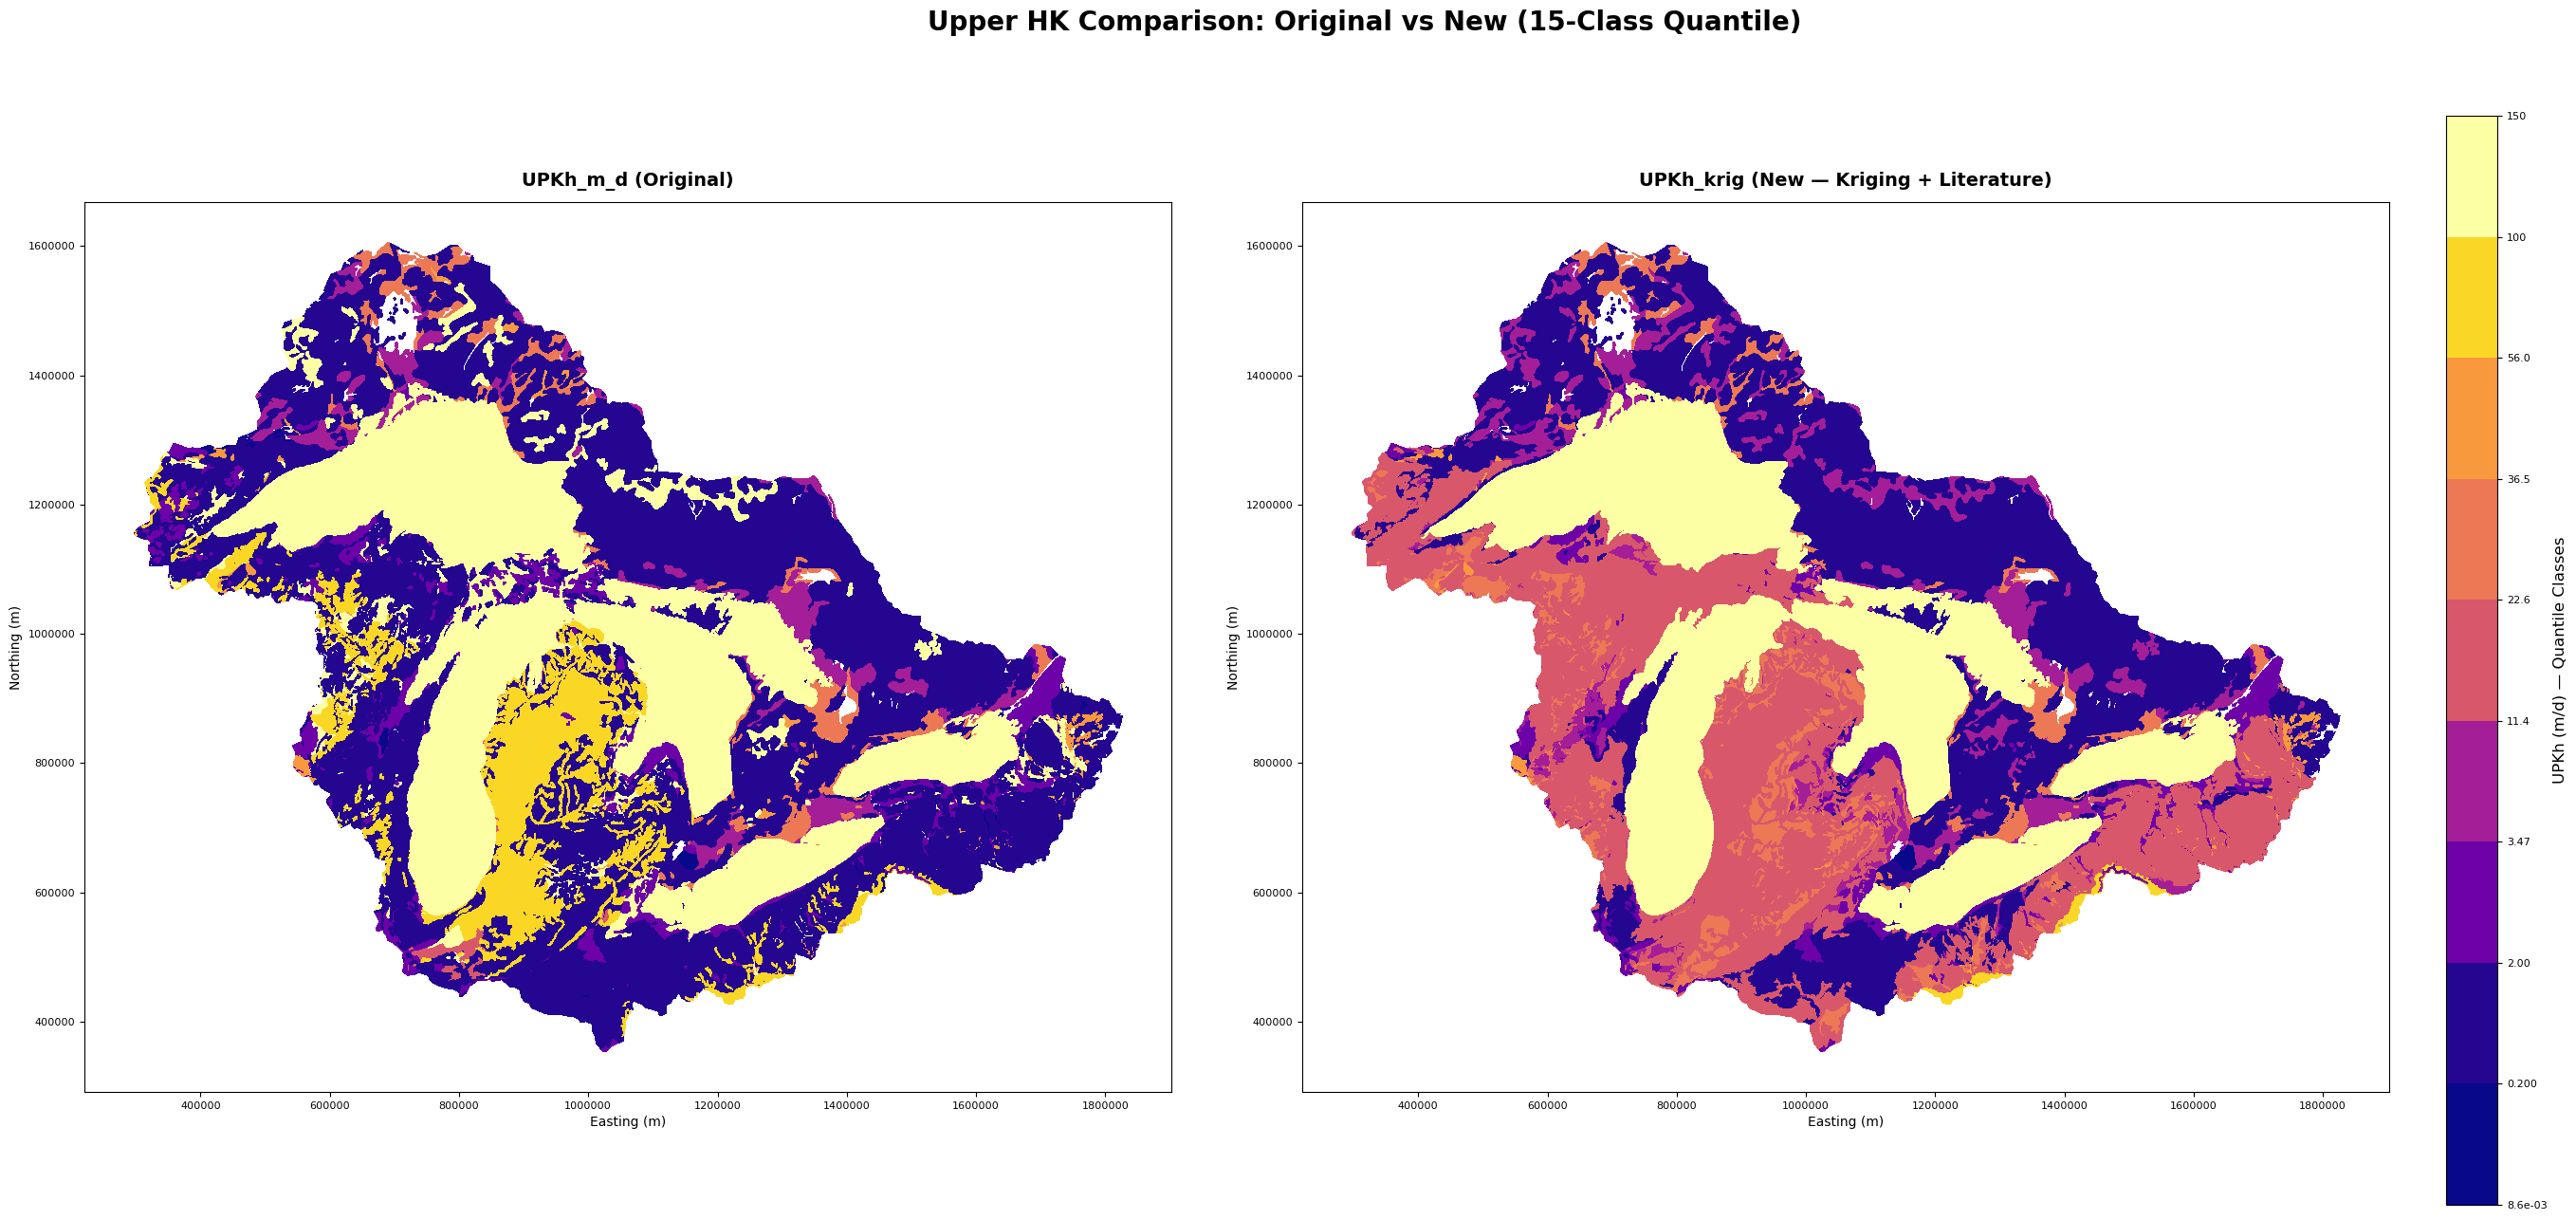


Plotting MidKh comparison (15-class quantile)...
  ✅ Saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\MidKh_comparison_quantile.png


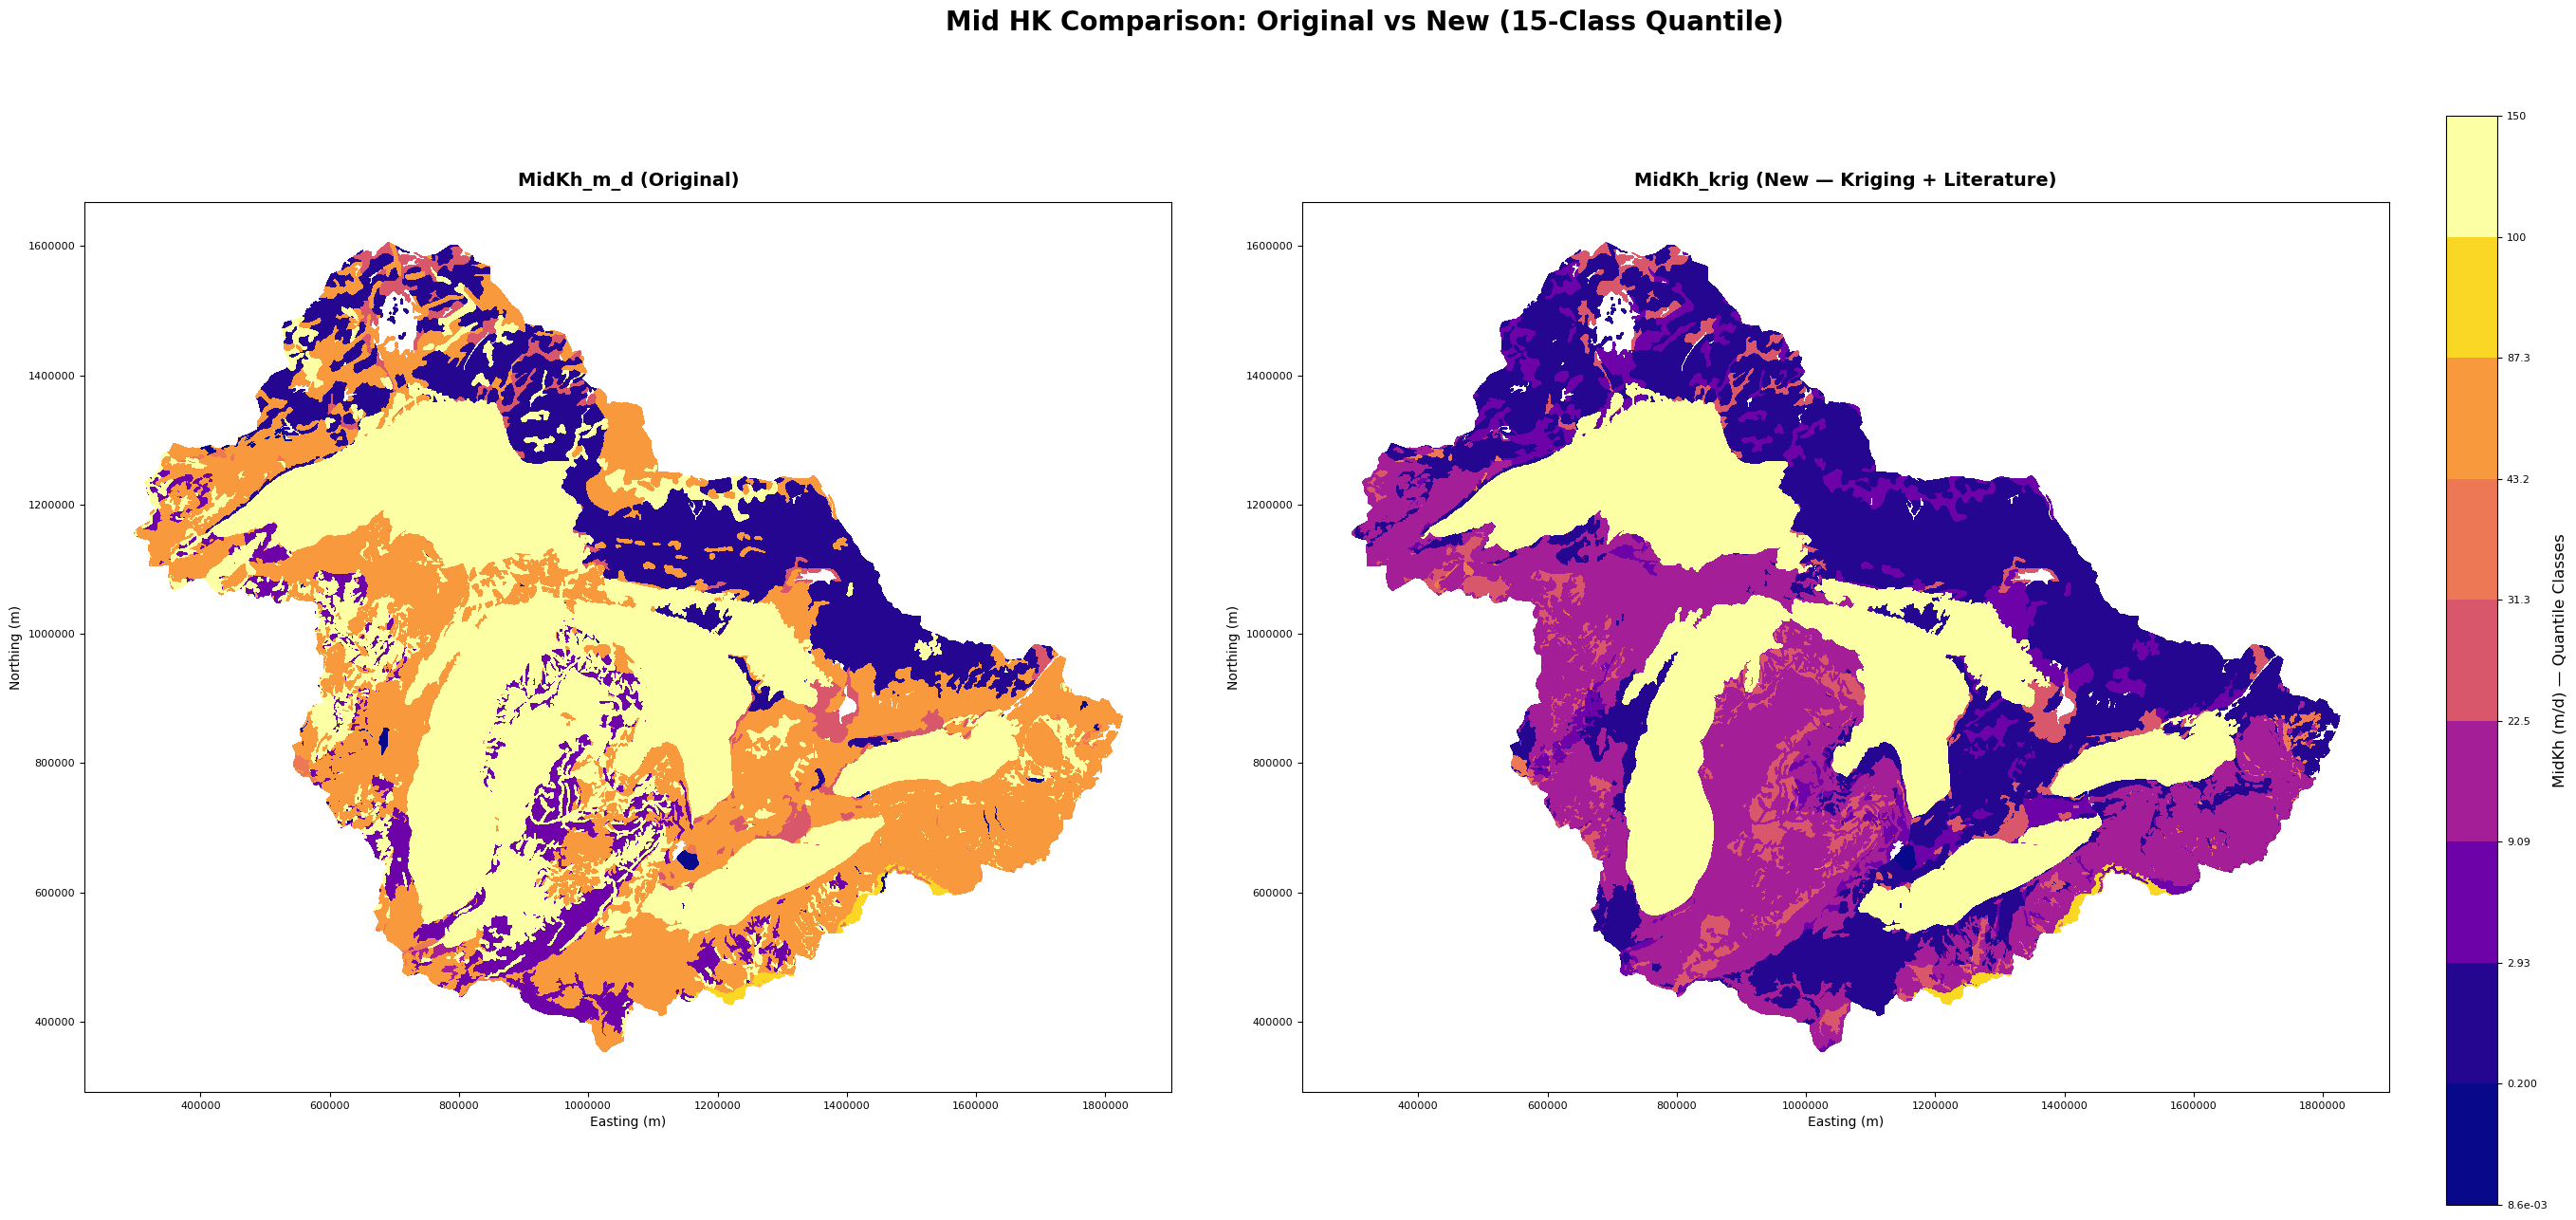


Plotting scatter comparisons...
  ✅ Saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_scatter_comparison.png


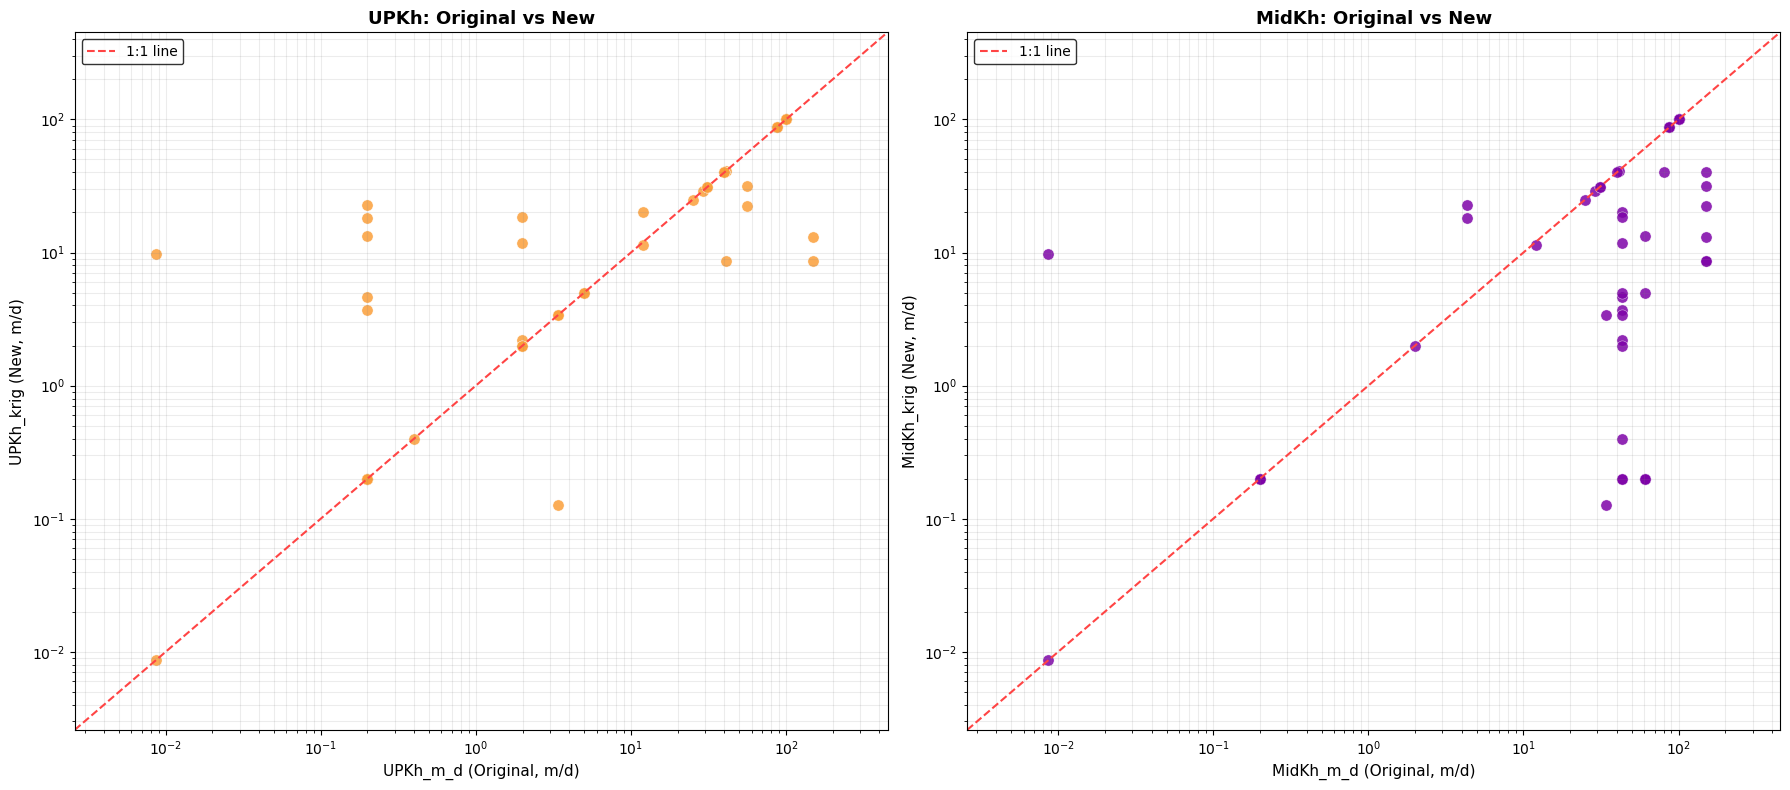


✅ All comparison plots complete.


In [45]:
# ============================================================
# Cell 29 — Spatial Comparison Maps (MORE QUANTILE CLASSES)
# WHITE BACKGROUND VERSION
# ============================================================

import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

print("Reading polygon geometries and values...")

records = []

with arcpy.da.SearchCursor(
        poly_3174, ["UNIQ_ID", "SHAPE@", "UPKh_m_d", "UPKh_krig", 
                     "MidKh_m_d", "MidKh_krig"]) as cur:
    for row in cur:
        uid, shape, up_md, up_kr, mid_md, mid_kr = row
        
        poly_paths = []
        for i in range(shape.partCount):
            part = shape.getPart(i)
            coords = []
            for pt in part:
                if pt is None:
                    break
                coords.append((pt.X, pt.Y))
            if len(coords) > 2:
                poly_paths.append(coords)
        
        records.append({
            "UNIQ_ID":    uid,
            "paths":      poly_paths,
            "UPKh_m_d":   up_md if up_md is not None and up_md > 0 else 0.001,
            "UPKh_krig":  up_kr if up_kr is not None and up_kr > 0 else 0.001,
            "MidKh_m_d":  mid_md if mid_md is not None and mid_md > 0 else 0.001,
            "MidKh_krig": mid_kr if mid_kr is not None and mid_kr > 0 else 0.001
        })

print(f"  ✅ {len(records)} polygons read.")

# 15-class colormap with distinct colors
hk_colors_15 = [
    "#08088B",  # near black
    '#0D0887',  # deep blue
    '#2D0594',  # blue-purple
    '#5C01A6',  # violet
    '#7E03A8',  # magenta-purple
    '#9C179E',  # magenta
    '#BD3786',  # pink-magenta
    '#D8576B',  # salmon
    '#E8765C',  # light salmon
    '#ED7953',  # orange
    '#F89441',  # bright orange
    '#FB9F3A',  # light orange
    '#FDCA26',  # gold
    '#F0F921',  # yellow
    '#FCFFA4',  # pale yellow
]
hk_cmap = LinearSegmentedColormap.from_list('hk_15class', hk_colors_15, N=512)

N_CLASSES = 15

def compute_quantile_bounds(records, key1, key2, n_classes):
    all_vals = []
    for rec in records:
        for key in [key1, key2]:
            v = rec[key]
            if v is not None and v > 0.001:
                all_vals.append(v)
    
    all_vals = np.array(sorted(all_vals))
    percentiles = np.linspace(0, 100, n_classes + 1)
    bounds = np.percentile(all_vals, percentiles)
    bounds = np.unique(bounds)
    
    return bounds, all_vals

def plot_hk_map_quantile(ax, records, value_key, title, bounds, cmap):
    
    patches = []
    values  = []
    
    for rec in records:
        val = rec[value_key]
        if val is None or val <= 0:
            val = bounds[0]
        for coords in rec["paths"]:
            poly = MplPolygon(coords, closed=True)
            patches.append(poly)
            values.append(val)
    
    values = np.array(values, dtype=float)
    values = np.clip(values, bounds[0], bounds[-1])
    
    norm = BoundaryNorm(bounds, cmap.N)
    
    pc = PatchCollection(
        patches,
        cmap=cmap,
        norm=norm,
        edgecolor='face',
        linewidth=0,
        antialiased=False,
        rasterized=True
    )
    pc.set_array(values)
    ax.add_collection(pc)
    
    ax.autoscale()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12, color='black')
    ax.ticklabel_format(style='plain', axis='both')
    ax.tick_params(labelsize=8, colors='black')
    ax.set_xlabel("Easting (m)", fontsize=10, color='black')
    ax.set_ylabel("Northing (m)", fontsize=10, color='black')
    ax.set_facecolor('white')
    
    for spine in ax.spines.values():
        spine.set_color('black')
    
    return pc, norm

def format_tick(v):
    if v >= 100:
        return f"{v:.0f}"
    elif v >= 10:
        return f"{v:.1f}"
    elif v >= 1:
        return f"{v:.2f}"
    elif v >= 0.01:
        return f"{v:.3f}"
    else:
        return f"{v:.1e}"

# ============================================================
# Compute shared quantile boundaries
# ============================================================
up_bounds, up_all   = compute_quantile_bounds(records, "UPKh_m_d", "UPKh_krig", N_CLASSES)
mid_bounds, mid_all = compute_quantile_bounds(records, "MidKh_m_d", "MidKh_krig", N_CLASSES)

print(f"\n  UPKh quantile boundaries ({len(up_bounds)-1} classes):")
for i in range(len(up_bounds)-1):
    print(f"    Class {i+1:>2}: {format_tick(up_bounds[i]):>10} — {format_tick(up_bounds[i+1]):>10} m/d")

print(f"\n  MidKh quantile boundaries ({len(mid_bounds)-1} classes):")
for i in range(len(mid_bounds)-1):
    print(f"    Class {i+1:>2}: {format_tick(mid_bounds[i]):>10} — {format_tick(mid_bounds[i+1]):>10} m/d")

# ============================================================
# FIGURE 1: UPKh
# ============================================================
print("\nPlotting UPKh comparison (15-class quantile)...")

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 14), facecolor='white')
fig1.subplots_adjust(wspace=0.12, right=0.86, left=0.05, top=0.90, bottom=0.06)

pc1, norm1 = plot_hk_map_quantile(
    ax1, records, "UPKh_m_d", "UPKh_m_d (Original)",
    bounds=up_bounds, cmap=hk_cmap
)
pc2, norm2 = plot_hk_map_quantile(
    ax2, records, "UPKh_krig", "UPKh_krig (New — Kriging + Literature)",
    bounds=up_bounds, cmap=hk_cmap
)

cbar_ax = fig1.add_axes([0.88, 0.06, 0.018, 0.82])
cbar_ax.set_facecolor('white')
cb = fig1.colorbar(pc2, cax=cbar_ax, spacing='uniform')
cb.set_label("UPKh (m/d) — Quantile Classes", fontsize=12, color='black')
cb.set_ticks(up_bounds)
cb.set_ticklabels([format_tick(v) for v in up_bounds])
cb.ax.tick_params(labelsize=8, colors='black')
cb.outline.set_edgecolor('black')

fig1.suptitle(
    "Upper HK Comparison: Original vs New (15-Class Quantile)",
    fontsize=20, fontweight='bold', y=0.96, color='black'
)

fig1_path = os.path.join(os.path.dirname(gdb), "UPKh_comparison_quantile.png")
fig1.savefig(fig1_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"  ✅ Saved: {fig1_path}")
plt.show()

# ============================================================
# FIGURE 2: MidKh
# ============================================================
print("\nPlotting MidKh comparison (15-class quantile)...")

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(30, 14), facecolor='white')
fig2.subplots_adjust(wspace=0.12, right=0.86, left=0.05, top=0.90, bottom=0.06)

pc3, norm3 = plot_hk_map_quantile(
    ax3, records, "MidKh_m_d", "MidKh_m_d (Original)",
    bounds=mid_bounds, cmap=hk_cmap
)
pc4, norm4 = plot_hk_map_quantile(
    ax4, records, "MidKh_krig", "MidKh_krig (New — Kriging + Literature)",
    bounds=mid_bounds, cmap=hk_cmap
)

cbar_ax2 = fig2.add_axes([0.88, 0.06, 0.018, 0.82])
cbar_ax2.set_facecolor('white')
cb2 = fig2.colorbar(pc4, cax=cbar_ax2, spacing='uniform')
cb2.set_label("MidKh (m/d) — Quantile Classes", fontsize=12, color='black')
cb2.set_ticks(mid_bounds)
cb2.set_ticklabels([format_tick(v) for v in mid_bounds])
cb2.ax.tick_params(labelsize=8, colors='black')
cb2.outline.set_edgecolor('black')

fig2.suptitle(
    "Mid HK Comparison: Original vs New (15-Class Quantile)",
    fontsize=20, fontweight='bold', y=0.96, color='black'
)

fig2_path = os.path.join(os.path.dirname(gdb), "MidKh_comparison_quantile.png")
fig2.savefig(fig2_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"  ✅ Saved: {fig2_path}")
plt.show()

# ============================================================
# FIGURE 3: Scatter plots
# ============================================================
print("\nPlotting scatter comparisons...")

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

for ax in [ax5, ax6]:
    ax.set_facecolor('white')
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')

up_old, up_new = [], []
for rec in records:
    if rec["UPKh_m_d"] > 0.001 and rec["UPKh_krig"] > 0.001:
        up_old.append(rec["UPKh_m_d"])
        up_new.append(rec["UPKh_krig"])

ax5.scatter(up_old, up_new, c='#FB9F3A', edgecolor='white', linewidth=0.3, s=65, alpha=0.85)
lims = [min(min(up_old), min(up_new)) * 0.3, max(max(up_old), max(up_new)) * 3]
ax5.plot(lims, lims, '--', color='#FF4444', linewidth=1.5, label='1:1 line')
ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.set_xlim(lims)
ax5.set_ylim(lims)
ax5.set_xlabel("UPKh_m_d (Original, m/d)", fontsize=11, color='black')
ax5.set_ylabel("UPKh_krig (New, m/d)", fontsize=11, color='black')
ax5.set_title("UPKh: Original vs New", fontsize=13, fontweight='bold', color='black')
ax5.legend(fontsize=10, facecolor='white', edgecolor='black', labelcolor='black')
ax5.grid(True, alpha=0.15, which='both', color='gray')

mid_old, mid_new = [], []
for rec in records:
    if rec["MidKh_m_d"] > 0.001 and rec["MidKh_krig"] > 0.001:
        mid_old.append(rec["MidKh_m_d"])
        mid_new.append(rec["MidKh_krig"])

ax6.scatter(mid_old, mid_new, c='#7E03A8', edgecolor='white', linewidth=0.3, s=65, alpha=0.85)
lims2 = [min(min(mid_old), min(mid_new)) * 0.3, max(max(mid_old), max(mid_new)) * 3]
ax6.plot(lims2, lims2, '--', color='#FF4444', linewidth=1.5, label='1:1 line')
ax6.set_xscale('log')
ax6.set_yscale('log')
ax6.set_xlim(lims2)
ax6.set_ylim(lims2)
ax6.set_xlabel("MidKh_m_d (Original, m/d)", fontsize=11, color='black')
ax6.set_ylabel("MidKh_krig (New, m/d)", fontsize=11, color='black')
ax6.set_title("MidKh: Original vs New", fontsize=13, fontweight='bold', color='black')
ax6.legend(fontsize=10, facecolor='white', edgecolor='black', labelcolor='black')
ax6.grid(True, alpha=0.15, which='both', color='gray')

plt.tight_layout()
fig3_path = os.path.join(os.path.dirname(gdb), "HK_scatter_comparison.png")
fig3.savefig(fig3_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"  ✅ Saved: {fig3_path}")
plt.show()

print("\n✅ All comparison plots complete.")

In [26]:
# ============================================================
# Cell 29b — Export Final Polygon to Shapefile
# ============================================================

output_folder = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"
output_name   = "Modified_HK_litkrig.shp"
output_path   = os.path.join(output_folder, output_name)

print(f"Exporting polygon to shapefile...")
print(f"  Source     : {poly_3174}")
print(f"  Destination: {output_path}")

delete_if_exists(output_path)

arcpy.conversion.FeatureClassToFeatureClass(
    poly_3174,
    output_folder,
    output_name
)

# Verify
count = int(arcpy.management.GetCount(output_path).getOutput(0))
print(f"\n  ✅ Exported: {output_path}")
print(f"  ✅ Total polygons: {count}")

Exporting polygon to shapefile...
  Source     : D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_join_clip.gdb\poly_3174
  Destination: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\Modified_HK_litkrig.shp

  ✅ Exported: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\Modified_HK_litkrig.shp
  ✅ Total polygons: 74


## Rasterize HK polygons to a multi-band GeoTIFF

Converts each HK field to a raster on the model grid and composites the five rasters into one multi-band GeoTIFF for model input.

1- rasterizes each of the 5 HK fields
2- finds gaps inside the model domain
3- fills them from the nearest valid neighbor
4- keeps land and lake separated by using water_mask_raster as the zone raster
5- then composites the 5 filled rasters into the multiband TIFF

In [37]:
# Check: do any polygons with value=100 overlap LAND zone cells?
from arcpy.sa import Raster, Con, IsNull

zone_ras = Raster(zone_1000m_path)
band = Raster(os.path.join(tmp_dir, "UPKh_krig.tif"))

# Cells where: zone says LAND but band value is 100 (lake-ish)
suspicious = Con((zone_ras == 1) & (band == 100), 1)
suspicious_path = os.path.join(tmp_dir, "suspicious.tif")
suspicious.save(suspicious_path)

# Count
arr = arcpy.RasterToNumPyArray(suspicious_path, nodata_to_value=0)
import numpy as np
print(f"Land cells with band=100 (mismatch): {int((arr == 1).sum()):,}")

Land cells with band=100 (mismatch): 3,271


In [38]:
# Inside your loop, replace the LAND section with this:

# ---- LAND: nibble from nearest LAND polygon cell ----
# But FIRST remove any cells where value=100 (lake contamination)
print(f"      Nibble-filling land gaps...")
band_land = Con(zone_ras == 1, band_clean)

# For UPKh_krig and MidKh_krig, 100 is a lake-only value — remove it from land sources
if f in ("UPKh_krig", "MidKh_krig"):
    band_land = SetNull(band_land == 100, band_land)

mask_land = Con(~IsNull(band_land), 1)
land_filled = Nibble(
    in_raster=band_land,
    in_mask_raster=mask_land,
    nibble_values="DATA_ONLY",
    nibble_nodata="PROCESS_NODATA"
)

      Nibble-filling land gaps...


In [36]:
# ============================================================
# Cell 31 — 5-Band HK Raster @ 1000m — NEAREST-NEIGHBOR FILL (both zones)
# ============================================================
from arcpy.sa import Raster, Con, IsNull, Nibble, SetNull
import os

# ---- INPUTS ----
template_raster   = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_1000m_epsg3174.tif"
water_mask_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff20000m.tif"
out_dir           = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"

fields_5_layers = ["UPKh_krig", "MidKh_krig", "LowKh_m_d", "FracKh_m_d", "BedKh_m_d"]

os.makedirs(out_dir, exist_ok=True)
out_multiband = os.path.join(out_dir, "HK_5band_1000m.tif")
tmp_dir = os.path.join(out_dir, "_tmp_hk5")
os.makedirs(tmp_dir, exist_ok=True)

arcpy.env.snapRaster             = template_raster
arcpy.env.cellSize               = template_raster
arcpy.env.extent                 = template_raster
arcpy.env.outputCoordinateSystem = arcpy.Describe(template_raster).spatialReference
arcpy.env.overwriteOutput        = True

# ---- Align zone raster to 1000m template ----
print("Aligning water mask to 1000m template...")
zone_1000m_path = os.path.join(tmp_dir, "zone_1000m.tif")
if arcpy.Exists(zone_1000m_path):
    arcpy.management.Delete(zone_1000m_path)

tmpl_desc = arcpy.Describe(template_raster)
arcpy.management.ProjectRaster(
    in_raster=water_mask_raster,
    out_raster=zone_1000m_path,
    out_coor_system=tmpl_desc.spatialReference,
    resampling_type="NEAREST",
    cell_size=tmpl_desc.meanCellWidth
)
zone_ras = Raster(zone_1000m_path)
print(f"  ✅ Zone aligned.")

print("\nConverting Polygons to 5-Band Raster Array...")
band_rasters = []

for f in fields_5_layers:
    out_ras    = os.path.join(tmp_dir, f"{f}.tif")
    filled_ras = os.path.join(tmp_dir, f"{f}_filled.tif")
    
    for p in [out_ras, filled_ras]:
        if arcpy.Exists(p):
            arcpy.management.Delete(p)
    
    print(f"\n   -> Rasterizing: {f}")
    arcpy.conversion.PolygonToRaster(
        in_features=poly_3174,
        value_field=f,
        out_rasterdataset=out_ras,
        cell_assignment="MAXIMUM_AREA",
        priority_field="NONE",
        cellsize=arcpy.env.cellSize
    )
    
    band = Raster(out_ras)
    # Treat 0 as a gap (NoData)
    band_clean = SetNull(band == 0, band)
    
    # ---- LAND: nibble from nearest LAND polygon cell ----
    print(f"      Nibble-filling land gaps...")
    band_land = Con(zone_ras == 1, band_clean)
    mask_land = Con(~IsNull(band_land), 1)
    land_filled = Nibble(
        in_raster=band_land,
        in_mask_raster=mask_land,
        nibble_values="DATA_ONLY",
        nibble_nodata="PROCESS_NODATA"
    )
    
    # ---- LAKE: nibble from nearest LAKE polygon cell ----
    print(f"      Nibble-filling lake gaps...")
    band_lake = Con(zone_ras == -1, band_clean)
    mask_lake = Con(~IsNull(band_lake), 1)
    lake_filled = Nibble(
        in_raster=band_lake,
        in_mask_raster=mask_lake,
        nibble_values="DATA_ONLY",
        nibble_nodata="PROCESS_NODATA"
    )
    
    # ---- Composite by zone ----
    print(f"      Compositing zones...")
    final = Con(
        zone_ras == 1,  land_filled,        # land -> nibbled land values
        Con(zone_ras == -1, lake_filled)    # lake -> nibbled lake values; else NoData
    )
    
    final.save(filled_ras)
    band_rasters.append(filled_ras)
    print(f"      ✅ {f} done.")

print("\nCompositing into final multi-band TIF...")
if arcpy.Exists(out_multiband):
    arcpy.management.Delete(out_multiband)
arcpy.management.CompositeBands(band_rasters, out_multiband)

print("=======================================")
print(f"🎉 SUCCESS: {out_multiband}")
print("=======================================")

# ---- Verify ----
print("\nVerifying fill...")
for i, f in enumerate(fields_5_layers, 1):
    b = f"Band_{i}"
    mn = arcpy.management.GetRasterProperties(out_multiband, "MINIMUM", b).getOutput(0)
    mx = arcpy.management.GetRasterProperties(out_multiband, "MAXIMUM", b).getOutput(0)
    print(f"   {b} ({f}): min={mn}, max={mx}")

arcpy.env.snapRaster = None
arcpy.env.cellSize = None
arcpy.env.extent = None
arcpy.env.outputCoordinateSystem = None

Aligning water mask to 1000m template...
  ✅ Zone aligned.

Converting Polygons to 5-Band Raster Array...

   -> Rasterizing: UPKh_krig
      Nibble-filling land gaps...
      Nibble-filling lake gaps...
      Compositing zones...
      ✅ UPKh_krig done.

   -> Rasterizing: MidKh_krig
      Nibble-filling land gaps...
      Nibble-filling lake gaps...
      Compositing zones...
      ✅ MidKh_krig done.

   -> Rasterizing: LowKh_m_d
      Nibble-filling land gaps...
      Nibble-filling lake gaps...
      Compositing zones...
      ✅ LowKh_m_d done.

   -> Rasterizing: FracKh_m_d
      Nibble-filling land gaps...
      Nibble-filling lake gaps...
      Compositing zones...
      ✅ FracKh_m_d done.

   -> Rasterizing: BedKh_m_d
      Nibble-filling land gaps...
      Nibble-filling lake gaps...
      Compositing zones...
      ✅ BedKh_m_d done.

Compositing into final multi-band TIF...
🎉 SUCCESS: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_1000m.tif

Veri

In [44]:
# ============================================================
# Cell 31 — 5-Band HK Raster @ 1000m — Clipped to Ibound Boundary
# ============================================================
from arcpy.sa import Raster, Con, IsNull, Nibble, SetNull, ExtractByMask
import os

# ---- INPUTS ----
template_raster   = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_1000m_epsg3174.tif"
water_mask_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff20000m.tif"
ibound_boundary   = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"
out_dir           = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"

fields_5_layers = ["UPKh_krig", "MidKh_krig", "LowKh_m_d", "FracKh_m_d", "BedKh_m_d"]

# Explicit values to use in LAKE zone
lake_fill_constants = {
    "UPKh_krig":  100.0,
    "MidKh_krig": 100.0,
    "LowKh_m_d":  0.00864,
    "FracKh_m_d": 0.0864,
    "BedKh_m_d":  0.000009,
}

os.makedirs(out_dir, exist_ok=True)
out_multiband = os.path.join(out_dir, "HK_5band_1000m.tif")
tmp_dir = os.path.join(out_dir, "_tmp_hk5")
os.makedirs(tmp_dir, exist_ok=True)

arcpy.env.snapRaster             = template_raster
arcpy.env.cellSize               = template_raster
arcpy.env.extent                 = template_raster
arcpy.env.outputCoordinateSystem = arcpy.Describe(template_raster).spatialReference
arcpy.env.overwriteOutput        = True

# ---- Align zone raster to 1000m template ----
print("Aligning water mask to 1000m template...")
zone_1000m_path = os.path.join(tmp_dir, "zone_1000m.tif")
if arcpy.Exists(zone_1000m_path):
    arcpy.management.Delete(zone_1000m_path)

tmpl_desc = arcpy.Describe(template_raster)
arcpy.management.ProjectRaster(
    in_raster=water_mask_raster,
    out_raster=zone_1000m_path,
    out_coor_system=tmpl_desc.spatialReference,
    resampling_type="NEAREST",
    cell_size=tmpl_desc.meanCellWidth
)
zone_ras = Raster(zone_1000m_path)
print(f"  ✅ Zone aligned.")

# ---- Rasterize ibound boundary to template grid for clipping ----
print("\nRasterizing ibound boundary for final clip...")
bdry_mask_path = os.path.join(tmp_dir, "bdry_mask.tif")
if arcpy.Exists(bdry_mask_path):
    arcpy.management.Delete(bdry_mask_path)

# Add a temp field if it doesn't have one to rasterize by
arcpy.conversion.PolygonToRaster(
    in_features=ibound_boundary,
    value_field="FID",  # any field works; we just need presence
    out_rasterdataset=bdry_mask_path,
    cell_assignment="MAXIMUM_AREA",
    priority_field="NONE",
    cellsize=arcpy.env.cellSize
)
bdry_ras = Raster(bdry_mask_path)
# Make it a clean 1/NoData mask
bdry_mask = Con(~IsNull(bdry_ras), 1)
print(f"  ✅ Boundary mask ready.")

print("\nConverting Polygons to 5-Band Raster Array...")
band_rasters = []

for f in fields_5_layers:
    lake_val = lake_fill_constants[f]
    out_ras    = os.path.join(tmp_dir, f"{f}.tif")
    filled_ras = os.path.join(tmp_dir, f"{f}_filled.tif")
    
    for p in [out_ras, filled_ras]:
        if arcpy.Exists(p):
            arcpy.management.Delete(p)
    
    print(f"\n   -> Rasterizing: {f}  (lake fill = {lake_val})")
    arcpy.conversion.PolygonToRaster(
        in_features=poly_3174,
        value_field=f,
        out_rasterdataset=out_ras,
        cell_assignment="MAXIMUM_AREA",
        priority_field="NONE",
        cellsize=arcpy.env.cellSize
    )
    
    band = Raster(out_ras)
    band_clean = SetNull(band == 0, band)
    
    # ---- LAND ZONE: nibble from nearest land polygon, scrub lake contamination ----
    print(f"      Nibble-filling land gaps...")
    band_land = Con(zone_ras == 1, band_clean)
    if f in ("UPKh_krig", "MidKh_krig", "LowKh_m_d"):
        band_land = SetNull(band_land == 100, band_land)
    
    mask_land = Con(~IsNull(band_land), 1)
    land_filled = Nibble(
        in_raster=band_land,
        in_mask_raster=mask_land,
        nibble_values="DATA_ONLY",
        nibble_nodata="PROCESS_NODATA"
    )
    
    # ---- LAKE ZONE: explicit constant ----
    print(f"      Setting lake cells to {lake_val}...")
    lake_filled = Con(zone_ras == -1, lake_val)
    
    # ---- Composite by zone ----
    composited = Con(
        zone_ras == 1,  land_filled,
        Con(zone_ras == -1, lake_filled)
    )
    
    # ---- FINAL CLIP to ibound boundary ----
    print(f"      Clipping to ibound boundary...")
    final = SetNull(IsNull(bdry_mask), composited)
    
    final.save(filled_ras)
    band_rasters.append(filled_ras)
    print(f"      ✅ {f} done.")

print("\nCompositing into final multi-band TIF...")
if arcpy.Exists(out_multiband):
    arcpy.management.Delete(out_multiband)
arcpy.management.CompositeBands(band_rasters, out_multiband)

print("=======================================")
print(f"🎉 SUCCESS: {out_multiband}")
print("=======================================")

# ---- Verify ----
print("\nVerifying fill...")
for i, f in enumerate(fields_5_layers, 1):
    b = f"Band_{i}"
    mn = arcpy.management.GetRasterProperties(out_multiband, "MINIMUM", b).getOutput(0)
    mx = arcpy.management.GetRasterProperties(out_multiband, "MAXIMUM", b).getOutput(0)
    print(f"   {b} ({f}): min={mn}, max={mx}")

arcpy.env.snapRaster = None
arcpy.env.cellSize = None
arcpy.env.extent = None
arcpy.env.outputCoordinateSystem = None

Aligning water mask to 1000m template...
  ✅ Zone aligned.

Rasterizing ibound boundary for final clip...
  ✅ Boundary mask ready.

Converting Polygons to 5-Band Raster Array...

   -> Rasterizing: UPKh_krig  (lake fill = 100.0)
      Nibble-filling land gaps...
      Setting lake cells to 100.0...
      Clipping to ibound boundary...
      ✅ UPKh_krig done.

   -> Rasterizing: MidKh_krig  (lake fill = 100.0)
      Nibble-filling land gaps...
      Setting lake cells to 100.0...
      Clipping to ibound boundary...
      ✅ MidKh_krig done.

   -> Rasterizing: LowKh_m_d  (lake fill = 0.00864)
      Nibble-filling land gaps...
      Setting lake cells to 0.00864...
      Clipping to ibound boundary...
      ✅ LowKh_m_d done.

   -> Rasterizing: FracKh_m_d  (lake fill = 0.0864)
      Nibble-filling land gaps...
      Setting lake cells to 0.0864...
      Clipping to ibound boundary...
      ✅ FracKh_m_d done.

   -> Rasterizing: BedKh_m_d  (lake fill = 9e-06)
      Nibble-filling land gap

✅ Saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_plot.png


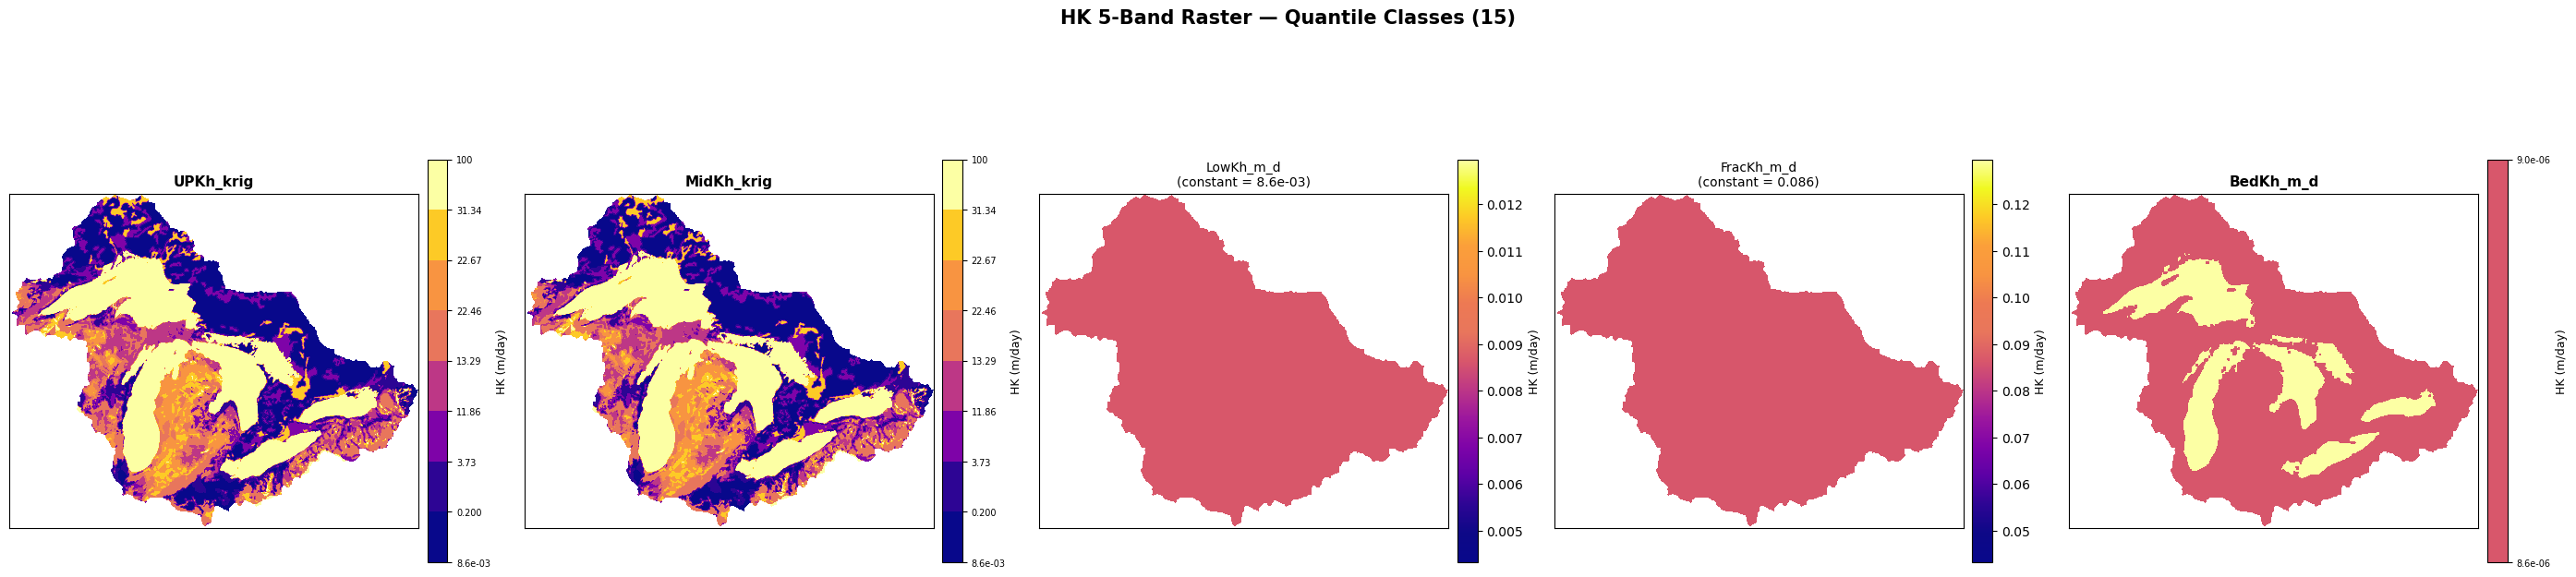

In [46]:
# ============================================================
# Plot 5 HK bands with the same quantile colormap as Cell 29
# ============================================================
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

hk_tif = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_1000m.tif"

band_names = ["UPKh_krig", "MidKh_krig", "LowKh_m_d", "FracKh_m_d", "BedKh_m_d"]

# Same 15-class colormap as Cell 29
hk_colors_15 = [
    "#08088B", "#0D0887", "#2D0594", "#5C01A6", "#7E03A8",
    "#9C179E", "#BD3786", "#D8576B", "#E8765C", "#ED7953",
    "#F89441", "#FB9F3A", "#FDCA26", "#F0F921", "#FCFFA4",
]
hk_cmap = LinearSegmentedColormap.from_list("hk_15class", hk_colors_15, N=512)
N_CLASSES = 15

def format_tick(v):
    if v < 0.01:
        return f"{v:.1e}"
    elif v < 1:
        return f"{v:.3f}"
    elif v < 100:
        return f"{v:.2f}"
    else:
        return f"{v:.0f}"

# Read all bands
with rasterio.open(hk_tif) as src:
    nodata = src.nodata
    arrays = []
    for i in range(1, src.count + 1):
        arr = src.read(i).astype(np.float32)
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
        arrays.append(arr)
    bounds_extent = src.bounds
    extent = [bounds_extent.left, bounds_extent.right, bounds_extent.bottom, bounds_extent.top]

# Plot 5 bands side by side
fig, axes = plt.subplots(1, 5, figsize=(28, 7), facecolor="white")

for i, (arr, name) in enumerate(zip(arrays, band_names)):
    ax = axes[i]
    finite = np.isfinite(arr) & (arr > 0)
    
    if finite.sum() == 0:
        ax.set_title(f"{name}\n(no data)", fontsize=10)
        ax.axis("off")
        continue
    
    vals = arr[finite]
    unique_vals = np.unique(vals)
    
    # If constant band (like Frac/Bed), just show one color
    if len(unique_vals) == 1:
        im = ax.imshow(arr, extent=extent, origin="upper",
                       cmap=hk_cmap, vmin=unique_vals[0]*0.5, vmax=unique_vals[0]*1.5)
        ax.set_title(f"{name}\n(constant = {format_tick(unique_vals[0])})",
                     fontsize=10, color="black")
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cb.set_label("HK (m/day)", fontsize=9)
    else:
        # Quantile boundaries
        q = np.linspace(0, 100, N_CLASSES + 1)
        qbounds = np.percentile(vals, q)
        qbounds = np.unique(qbounds)  # remove duplicates
        
        norm = BoundaryNorm(qbounds, ncolors=hk_cmap.N, clip=True)
        im = ax.imshow(arr, extent=extent, origin="upper", cmap=hk_cmap, norm=norm)
        ax.set_title(name, fontsize=11, fontweight="bold", color="black")
        
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, spacing="uniform")
        cb.set_label("HK (m/day)", fontsize=9)
        cb.set_ticks(qbounds)
        cb.set_ticklabels([format_tick(v) for v in qbounds])
        cb.ax.tick_params(labelsize=7)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("HK 5-Band Raster — Quantile Classes (15)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

out_png = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_plot.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight", facecolor="white")
print(f"✅ Saved: {out_png}")
plt.show()